# Ноутбук 041: Natural end-to-end RAG + расширенные retrieval/answer метрики

**Цель:** запустить более естественный end-to-end эксперимент по отдельным noisy-коллекциям, созданным в `040_create_natural_replacement_noisy_collections.ipynb`, и сразу посчитать ключевые метрики.

Отличие от controlled:

- в controlled контекст собирался вручную из `gold_mapping + noise_cache`;
- здесь каждый прогон делает обычный retrieval по одной Qdrant-коллекции;
- для `counterfactual` и `structural` шум уже внесён в коллекции через замену clean-фрагментов;
- для `semantic` шум добавлен как дополнительные похожие дистракторы.

Что считаем:

1. **Retrieval-метрики**: `gold_recall@3/5/10`, `related_recall@3/5/10`, `gold_mrr`, `gold_best_rank`, `own_noise_hits@5/10`.
2. **Answer-метрики**: `EM`, `F1`, `I don't know rate`.
3. **LLM-judge**: correctness и faithfulness с отдельным кэшем и безопасной остановкой при лимитах.


## Шаг 0. Установка зависимостей и подключение Drive

In [1]:
!pip install -q qdrant-client fastembed groq tqdm tenacity rank-bm25 flashrank pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.8/324.8 kB 9.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Шаг 1. Импорты и конфигурация

По умолчанию включены все основные методы. Если лимиты Groq быстро заканчиваются, можно временно убрать `query_expansion` или `hyde`, так как они требуют дополнительного LLM-вызова на каждый вопрос.


In [ ]:
import os
import re
import json
import time
import random
import string
import pickle
from pathlib import Path
from collections import Counter, defaultdict
from itertools import product
from dataclasses import dataclass

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =========================
# API keys and paths
# =========================
# Рекомендуемый вариант для Colab:
#   1) положи ключи в Secrets как GROQ_API_KEY_1, GROQ_API_KEY_2, ...
#   2) либо задай один ключ как GROQ_API_KEY
#   3) либо задай переменную окружения GROQ_API_KEYS="key1,key2,key3"
# Если удобнее, можно вручную вписать ключи в список MANUAL_GROQ_API_KEYS ниже.
MANUAL_GROQ_API_KEYS = [

]

try:
    from google.colab import userdata
    QDRANT_URL = " "
    QDRANT_API_KEY = " "

    GROQ_API_KEYS = []
    # Основной ключ, если он один
    try:
        v = userdata.get("GROQ_API_KEY")
        if v:
            GROQ_API_KEYS.append(v.strip())
    except Exception:
        pass
    # Несколько ключей: GROQ_API_KEY_1, GROQ_API_KEY_2, ...
    for i in range(1, 21):
        try:
            v = userdata.get(f"GROQ_API_KEY_{i}")
            if v:
                GROQ_API_KEYS.append(v.strip())
        except Exception:
            pass
except Exception:
    QDRANT_URL = os.environ.get("QDRANT_URL", "")
    QDRANT_API_KEY = os.environ.get("QDRANT_API_KEY", "")
    GROQ_API_KEYS = []

# Переменная окружения со списком ключей через запятую тоже поддерживается.
env_keys = os.environ.get("GROQ_API_KEYS", "")
if env_keys:
    GROQ_API_KEYS.extend([k.strip() for k in env_keys.split(",") if k.strip()])

# Ручной список добавляется последним.
GROQ_API_KEYS.extend([k.strip() for k in MANUAL_GROQ_API_KEYS if k.strip()])

# Удаляем дубликаты, сохраняя порядок.
_seen = set()
GROQ_API_KEYS = [k for k in GROQ_API_KEYS if not (k in _seen or _seen.add(k))]

assert QDRANT_URL, "Не найден QDRANT_URL. Укажи его в Colab Secrets или os.environ."
assert QDRANT_API_KEY, "Не найден QDRANT_API_KEY. Укажи его в Colab Secrets или os.environ."
assert GROQ_API_KEYS, (
    "Не найден ни один Groq API key. Добавь GROQ_API_KEY_1/GROQ_API_KEY_2 в Colab Secrets, "
    "или заполни MANUAL_GROQ_API_KEYS."
)

ARTIFACTS_DIR = Path("/content/drive/MyDrive/rag_experiment/artifacts")
assert ARTIFACTS_DIR.exists(), f"Не найдена папка артефактов: {ARTIFACTS_DIR}"

E2E_DIR = ARTIFACTS_DIR / "answers" / "end_to_end_natural"
E2E_DIR.mkdir(parents=True, exist_ok=True)

EVAL_DIR = ARTIFACTS_DIR / "evaluations" / "end_to_end_natural"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

BM25_CACHE_DIR = ARTIFACTS_DIR / "bm25_cache_natural"
BM25_CACHE_DIR.mkdir(parents=True, exist_ok=True)

NATURAL_CONFIG_PATH = ARTIFACTS_DIR / "end_to_end_replacement_collections_config.json"

EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
GENERATOR_MODEL = "llama-3.3-70b-versatile"
JUDGE_MODEL = os.environ.get("JUDGE_MODEL", "llama-3.1-8b-instant")
RERANKER_MODEL = "ms-marco-MiniLM-L-12-v2"

TOP_K_RETRIEVE = 20
TOP_K_FINAL = 5
GENERATOR_MAX_TOKENS = 150

# Natural end-to-end: clean запускаем один раз, потому что noise_type при level=0 не имеет смысла.
RUN_CLEAN_ONCE = True

NOISE_TYPES = ["semantic", "counterfactual", "structural"]
NOISE_LEVELS = [40, 80]

# Для полного сравнения можно оставить все пять. Для экономии чаще достаточно baseline/hyde/rerank/hybrid_rerank.
METHODS = ["baseline", "rerank", "hybrid_rerank"]

# Ограничение для отладки. Для полного прогона поставь None.
MAX_QUESTIONS = None

# Локальное сглаживание TPM на каждый ключ. Реальные лимиты Groq всё равно обрабатываются автоматически.
GROQ_TPM_BUDGET_PER_KEY = 5500
GROQ_REQUEST_DELAY = 0.4

print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("E2E_DIR:", E2E_DIR)
print("METHODS:", METHODS)
print("Groq keys loaded:", len(GROQ_API_KEYS))

ARTIFACTS_DIR: /content/drive/MyDrive/rag_experiment/artifacts
E2E_DIR: /content/drive/MyDrive/rag_experiment/artifacts/answers/end_to_end_natural
METHODS: ['baseline', 'rerank', 'hybrid_rerank']
Groq keys loaded: 9


## Шаг 2. Загрузка вопросов, gold mapping и конфигурации noisy-коллекций

In [4]:
with open(ARTIFACTS_DIR / "questions.json", encoding="utf-8") as f:
    questions = json.load(f)
with open(ARTIFACTS_DIR / "gold_mapping.json", encoding="utf-8") as f:
    gold_mapping = json.load(f)

assert NATURAL_CONFIG_PATH.exists(), (
    f"Не найден {NATURAL_CONFIG_PATH}. Сначала выполни 040_create_natural_replacement_noisy_collections.ipynb"
)
with open(NATURAL_CONFIG_PATH, encoding="utf-8") as f:
    natural_config = json.load(f)

if MAX_QUESTIONS is not None:
    questions = questions[:MAX_QUESTIONS]

COLLECTION_CLEAN = natural_config["collection_clean"]
COLLECTIONS_MAP = natural_config["collections"]

print(f"Вопросов: {len(questions)}")
print("Clean collection:", COLLECTION_CLEAN)
print("Коллекции natural end-to-end:")
for k, v in COLLECTIONS_MAP.items():
    print(f"  {k}: {v}")

print("Пример вопроса:")
print(questions[0])


Вопросов: 100
Clean collection: rag_clean
Коллекции natural end-to-end:
  0: rag_clean
  semantic__40: rag_noisy_semantic_40
  semantic__80: rag_noisy_semantic_80
  counterfactual__40: rag_noisy_counterfactual_replace_40
  counterfactual__80: rag_noisy_counterfactual_replace_80
  structural__40: rag_noisy_structural_replace_40
  structural__80: rag_noisy_structural_replace_80
Пример вопроса:
{'id': '5ae0f73d55429920d5234252', 'question': 'Where was the Super Bowl, that Alan Faneca won, played ?', 'answer': 'Ford Field in Detroit', 'type': 'bridge', 'level': 'hard', 'gold_titles': ['Alan Faneca', 'Super Bowl XL']}


## Шаг 3. Подключение к Qdrant, Groq, embedder и reranker

In [5]:
from qdrant_client import QdrantClient
from fastembed import TextEmbedding
from groq import Groq, RateLimitError, APIError, BadRequestError
from flashrank import Ranker, RerankRequest

qdrant = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY, timeout=120)
groq_clients = [Groq(api_key=k) for k in GROQ_API_KEYS]
embedder = TextEmbedding(model_name=EMBEDDING_MODEL)

print("Проверка коллекций:")
for key, cname in COLLECTIONS_MAP.items():
    info = qdrant.get_collection(cname)
    print(f"  {key:>24} -> {cname}: {info.points_count} points")

print(f"Groq clients ready: {len(groq_clients)}")
print("Загрузка reranker...")
reranker = Ranker(model_name=RERANKER_MODEL)
print("✅ Ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Проверка коллекций:
                         0 -> rag_clean: 7997 points
              semantic__40 -> rag_noisy_semantic_40: 8260 points
              semantic__80 -> rag_noisy_semantic_80: 8489 points
        counterfactual__40 -> rag_noisy_counterfactual_replace_40: 7997 points
        counterfactual__80 -> rag_noisy_counterfactual_replace_80: 7998 points
            structural__40 -> rag_noisy_structural_replace_40: 8004 points
            structural__80 -> rag_noisy_structural_replace_80: 8006 points
Groq clients ready: 9
Загрузка reranker...



ms-marco-MiniLM-L-12-v2.zip:   0%|          | 0.00/21.6M [00:00<?, ?iB/s]
ms-marco-MiniLM-L-12-v2.zip: 100%|██████████| 21.6M/21.6M [00:00<00:00, 136MiB/s] 


✅ Ready


## Шаг 4. Rate limiter, несколько Groq-ключей и LLM-вызовы

Если один Groq-ключ упирается в rate limit/quota, ноутбук автоматически переключается на следующий ключ. Если лимиты закончились на всех ключах, прогон безопасно остановится, а уже готовые ответы останутся в кэше.

In [6]:
class ExperimentLimitReached(Exception):
    pass

class GroqTokenBudget:
    def __init__(self, tpm_limit):
        self.tpm_limit = tpm_limit
        self.usage = []

    def _prune(self):
        cutoff = time.time() - 60
        self.usage = [(t, n) for t, n in self.usage if t > cutoff]

    def wait_if_needed(self, est_tokens, key_label=""):
        self._prune()
        used = sum(n for _, n in self.usage)
        if used + est_tokens > self.tpm_limit and self.usage:
            wait_sec = max(0, 60 - (time.time() - self.usage[0][0])) + 1
            print(f"⏳ Local TPM budget {key_label}: sleep {wait_sec:.1f}s")
            time.sleep(wait_sec)
            self._prune()

    def record(self, tokens):
        self.usage.append((time.time(), tokens))

class GroqKeyPool:
    def __init__(self, clients, tpm_limit_per_key):
        self.clients = clients
        self.budgets = [GroqTokenBudget(tpm_limit_per_key) for _ in clients]
        self.disabled = [False for _ in clients]
        self.disable_reasons = [None for _ in clients]
        self.current_idx = 0

    def has_available(self):
        return any(not x for x in self.disabled)

    def _advance_to_available(self):
        n = len(self.clients)
        for _ in range(n):
            if not self.disabled[self.current_idx]:
                return True
            self.current_idx = (self.current_idx + 1) % n
        return False

    def current(self):
        if not self._advance_to_available():
            return None, None, None
        return self.current_idx, self.clients[self.current_idx], self.budgets[self.current_idx]

    def disable_current(self, reason):
        idx = self.current_idx
        self.disabled[idx] = True
        self.disable_reasons[idx] = str(reason)[:500]
        print(f"⚠️ Groq key #{idx + 1} reached limit/quota. Switching to next key.")
        self.current_idx = (self.current_idx + 1) % len(self.clients)

    def status(self):
        rows = []
        for i, disabled in enumerate(self.disabled):
            rows.append({
                "key_index": i + 1,
                "active": not disabled,
                "disabled_reason": self.disable_reasons[i],
            })
        return pd.DataFrame(rows)

groq_key_pool = GroqKeyPool(groq_clients, GROQ_TPM_BUDGET_PER_KEY)

def estimate_tokens(text):
    return max(1, len(text) // 4)

def is_groq_limit_error(exc):
    text = str(exc).lower()
    return (
        isinstance(exc, RateLimitError)
        or "rate limit" in text
        or "quota" in text
        or "tokens per minute" in text
        or "too many requests" in text
        or "requests per minute" in text
    )

def groq_complete(prompt, model=GENERATOR_MODEL, max_tokens=150, temperature=0.0):
    """LLM call with automatic failover across several Groq keys."""
    est = estimate_tokens(prompt) + max_tokens
    last_errors = []

    while groq_key_pool.has_available():
        idx, client, key_budget = groq_key_pool.current()
        if client is None:
            break
        key_label = f"key #{idx + 1}"
        key_budget.wait_if_needed(est, key_label=key_label)

        # Небольшой retry на временные APIError. Rate limit/quota не ретраим на том же ключе, а переключаемся.
        for attempt in range(2):
            try:
                resp = client.chat.completions.create(
                    model=model,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=temperature,
                    max_tokens=max_tokens,
                )
                time.sleep(GROQ_REQUEST_DELAY)
                used = getattr(resp, "usage", None)
                total_tokens = getattr(used, "total_tokens", est) if used else est
                key_budget.record(total_tokens)
                return resp.choices[0].message.content.strip(), total_tokens
            except Exception as e:
                if is_groq_limit_error(e):
                    last_errors.append(f"{key_label}: {str(e)[:300]}")
                    groq_key_pool.disable_current(e)
                    break
                if isinstance(e, (APIError, BadRequestError)) and attempt == 0:
                    time.sleep(2)
                    continue
                raise

    msg = "All Groq keys reached limit/quota. Last errors:\n" + "\n".join(last_errors[-5:])
    raise ExperimentLimitReached(msg)

print("Groq key pool status:")
display(groq_key_pool.status())

Groq key pool status:


,key_index,active,disabled_reason
0,1,True,None
1,2,True,None
2,3,True,None
3,4,True,None
4,5,True,None
5,6,True,None
6,7,True,None
7,8,True,None
8,9,True,None


## Шаг 5. Natural retrieval: одна конфигурация → одна Qdrant-коллекция

Здесь нет ручного смешивания `% clean + % noise`. При каждом прогоне выбирается одна коллекция, и Qdrant сам возвращает top-k.


In [7]:
def config_items():
    if RUN_CLEAN_ONCE:
        yield "clean", 0
    else:
        for nt in NOISE_TYPES:
            yield nt, 0
    for nt in NOISE_TYPES:
        for lvl in NOISE_LEVELS:
            yield nt, lvl

def collection_for(noise_type, noise_level):
    if noise_level == 0 or noise_type == "clean":
        return COLLECTION_CLEAN
    key = f"{noise_type}__{noise_level}"
    if key not in COLLECTIONS_MAP:
        raise KeyError(f"Нет коллекции для {key}. Доступные ключи: {list(COLLECTIONS_MAP)}")
    return COLLECTIONS_MAP[key]

OWN_NOISE_ROLE = {
    "semantic": "injected_semantic_distractor",
    "counterfactual": "injected_counterfactual",
    "structural": "injected_structural",
    "clean": None,
}

def hit_to_doc(hit, collection_name, retrieved_by="dense"):
    p = hit.payload or {}
    return {
        "id": str(hit.id),
        "collection": collection_name,
        "title": p.get("title", ""),
        "text": p.get("text", ""),
        "role": p.get("role", "unknown"),
        "source_question_ids": p.get("source_question_ids", []),
        "source_question_id": p.get("source_question_id"),
        "based_on_title": p.get("based_on_title"),
        "noise_type": p.get("noise_type"),
        "score": float(hit.score) if getattr(hit, "score", None) is not None else None,
        "retrieved_by": retrieved_by,
    }

def doc_key(d):
    return f"{d.get('collection')}::{d.get('id')}::{d.get('title')}"

def dedupe_docs(docs):
    seen = set()
    out = []
    for d in docs:
        key = doc_key(d)
        if key in seen:
            continue
        seen.add(key)
        out.append(d)
    return out

def dense_search(query, collection_name, top_k=TOP_K_RETRIEVE):
    qvec = list(embedder.embed([query]))[0].tolist()
    hits = qdrant.query_points(
        collection_name=collection_name,
        query=qvec,
        limit=top_k,
        with_payload=True,
    ).points
    return [hit_to_doc(h, collection_name, retrieved_by="dense") for h in hits]

# Быстрая проверка natural retrieval
q0 = questions[0]
for nt, lvl in list(config_items())[:4]:
    cname = collection_for(nt, lvl)
    docs = dense_search(q0["question"], cname, top_k=5)
    print(f"\nconfig={nt}/{lvl}, collection={cname}")
    print(Counter(d["role"] for d in docs))
    for d in docs[:3]:
        print(" -", d["role"], "|", d["title"][:80])



config=clean/0, collection=rag_clean
Counter({'gold': 3, 'distractor': 1, 'background': 1})
 - gold | Alan Faneca
 - gold | Alan Faneca
 - gold | Super Bowl XL

config=semantic/40, collection=rag_noisy_semantic_40
Counter({'gold': 3, 'distractor': 1, 'injected_semantic_distractor': 1})
 - gold | Alan Faneca
 - gold | Alan Faneca
 - gold | Super Bowl XL

config=semantic/80, collection=rag_noisy_semantic_80
Counter({'gold': 3, 'distractor': 1, 'injected_semantic_distractor': 1})
 - gold | Alan Faneca
 - gold | Alan Faneca
 - gold | Super Bowl XL

config=counterfactual/40, collection=rag_noisy_counterfactual_replace_40
Counter({'gold': 3, 'distractor': 1, 'background': 1})
 - gold | Alan Faneca
 - gold | Alan Faneca
 - gold | Super Bowl XL


## Шаг 6. BM25 для hybrid retrieval

BM25 строится отдельно для каждой natural-коллекции и сохраняется в кэш. Это нужно для `hybrid_rerank`.


In [8]:
from rank_bm25 import BM25Okapi

TOKEN_RE = re.compile(r"[a-zA-Z0-9_]+")

def tokenize(text):
    return TOKEN_RE.findall((text or "").lower())

@dataclass
class BM25Store:
    collection_name: str
    docs: list
    tokenized: list
    bm25: object


def scroll_collection_docs(collection_name):
    docs = []
    offset = None
    while True:
        points, next_offset = qdrant.scroll(
            collection_name=collection_name,
            limit=512,
            offset=offset,
            with_payload=True,
            with_vectors=False,
        )
        if not points:
            break
        for p in points:
            payload = p.payload or {}
            docs.append({
                "id": str(p.id),
                "collection": collection_name,
                "title": payload.get("title", ""),
                "text": payload.get("text", ""),
                "role": payload.get("role", "unknown"),
                "source_question_ids": payload.get("source_question_ids", []),
                "source_question_id": payload.get("source_question_id"),
                "based_on_title": payload.get("based_on_title"),
                "noise_type": payload.get("noise_type"),
                "score": None,
                "retrieved_by": "bm25",
            })
        if next_offset is None:
            break
        offset = next_offset
    return docs


def load_or_build_bm25(collection_name):
    safe_name = re.sub(r"[^a-zA-Z0-9_\-]", "_", collection_name)
    cache_path = BM25_CACHE_DIR / f"{safe_name}.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            store = pickle.load(f)
        print(f"BM25 cache loaded: {collection_name}, docs={len(store.docs)}")
        return store

    print(f"Building BM25 for {collection_name}...")
    docs = scroll_collection_docs(collection_name)
    tokenized = [tokenize(d["title"] + " " + d["text"]) for d in tqdm(docs, desc=f"tokenize {collection_name}")]
    store = BM25Store(collection_name=collection_name, docs=docs, tokenized=tokenized, bm25=BM25Okapi(tokenized))
    with open(cache_path, "wb") as f:
        pickle.dump(store, f)
    print(f"BM25 cache saved: {cache_path}")
    return store

# Ленивая загрузка, чтобы не строить BM25 для коллекций, которые не понадобятся.
BM25_STORES = {}

def get_bm25_store(collection_name):
    if collection_name not in BM25_STORES:
        BM25_STORES[collection_name] = load_or_build_bm25(collection_name)
    return BM25_STORES[collection_name]


def bm25_search(query, collection_name, top_k=TOP_K_RETRIEVE):
    store = get_bm25_store(collection_name)
    qtok = tokenize(query)
    scores = store.bm25.get_scores(qtok)
    order = np.argsort(scores)[::-1]
    out = []
    for idx in order[:top_k]:
        d = dict(store.docs[int(idx)])
        d["score"] = float(scores[int(idx)])
        d["retrieved_by"] = "bm25"
        out.append(d)
    return out


## Шаг 7. Генерация ответа и методы улучшения retrieval

In [9]:
ANSWER_PROMPT = """You are a question-answering assistant. Answer the question using ONLY the provided context.

The context may contain noisy, irrelevant, duplicated, corrupted, or contradictory fragments.
Your task is to identify the most relevant evidence and provide the most likely answer based only on that evidence.

Important rules:
1. Do not use outside knowledge.
2. Do not mention that the context is noisy unless it is necessary.
3. If the context contains at least some relevant evidence, give the best possible short answer.
4. If several fragments conflict, prefer the fragment that is most directly related to the question.
5. Answer exactly "I don't know" only if the provided context contains no relevant information for answering the question.
6. Keep the answer concise: usually 1-5 words, unless a short phrase is necessary.

Question:
{question}

Context:
{context}

Answer:"""

QUERY_EXPANSION_PROMPT = """Generate 3 alternative search queries for the question.
Return only the queries, one per line.

Question: {question}"""

HYDE_PROMPT = """Write a short hypothetical answer paragraph that would likely contain the information needed to answer the question.
Do not say that it is hypothetical. Return only the paragraph.

Question: {question}"""


def format_context(docs, max_chars_per_doc=1200):
    parts = []
    for i, d in enumerate(docs, 1):
        text = (d.get("text") or "")[:max_chars_per_doc]
        title = d.get("title", "")
        role = d.get("role", "")
        parts.append(f"[{i}] Title: {title}\nRole: {role}\nText: {text}")
    return "\n\n".join(parts)


def generate_answer(question, context_docs):
    prompt = ANSWER_PROMPT.format(question=question, context=format_context(context_docs))
    return groq_complete(prompt, max_tokens=GENERATOR_MAX_TOKENS, temperature=0.0)


def parse_query_lines(text):
    lines = []
    for line in (text or "").splitlines():
        line = re.sub(r"^[-*\d\.\)\s]+", "", line).strip().strip('"')
        if line:
            lines.append(line)
    return lines[:3]


def rrf_rank_from_rankings(rankings, k_rrf=60):
    scores = defaultdict(float)
    for ranking in rankings:
        for rank, key in enumerate(ranking, start=1):
            scores[key] += 1.0 / (k_rrf + rank)
    return [key for key, _ in sorted(scores.items(), key=lambda x: -x[1])]


def rerank_docs(question, docs, top_k=TOP_K_FINAL):
    docs = dedupe_docs(docs)
    if not docs:
        return [], []
    passages = [
        {"id": i, "text": d.get("text", ""), "meta": {"title": d.get("title"), "role": d.get("role")}}
        for i, d in enumerate(docs)
    ]
    ranked = reranker.rerank(RerankRequest(query=question, passages=passages))
    reordered = [docs[r["id"]] for r in ranked]
    scores = [float(r["score"]) for r in ranked]
    return reordered[:top_k], scores[:top_k]


def method_baseline(q, collection_name):
    candidates = dense_search(q["question"], collection_name, top_k=TOP_K_RETRIEVE)
    final_context = candidates[:TOP_K_FINAL]
    answer, tokens = generate_answer(q["question"], final_context)
    return {"answer": answer, "candidates": candidates, "final_context": final_context, "tokens": tokens, "extra_calls": 0}


def method_query_expansion(q, collection_name):
    expansions_text, exp_tokens = groq_complete(
        QUERY_EXPANSION_PROMPT.format(question=q["question"]),
        max_tokens=120,
        temperature=0.2,
    )
    queries = [q["question"]] + parse_query_lines(expansions_text)
    all_docs = []
    rankings = []
    by_key = {}
    per_query_k = max(5, TOP_K_RETRIEVE // max(len(queries), 1))
    for query in queries:
        docs = dense_search(query, collection_name, top_k=TOP_K_RETRIEVE)
        all_docs.extend(docs[:per_query_k])
        for d in docs:
            by_key[doc_key(d)] = d
        rankings.append([doc_key(d) for d in docs])
    fused_keys = rrf_rank_from_rankings(rankings)
    candidates = [by_key[k] for k in fused_keys if k in by_key][:TOP_K_RETRIEVE]
    if len(candidates) < TOP_K_RETRIEVE:
        candidates = dedupe_docs(candidates + all_docs)[:TOP_K_RETRIEVE]
    final_context = candidates[:TOP_K_FINAL]
    answer, ans_tokens = generate_answer(q["question"], final_context)
    return {
        "answer": answer,
        "candidates": candidates,
        "final_context": final_context,
        "tokens": exp_tokens + ans_tokens,
        "extra_calls": 1,
        "expanded_queries": queries[1:],
    }


def method_hyde(q, collection_name):
    hypothesis, hyp_tokens = groq_complete(
        HYDE_PROMPT.format(question=q["question"]),
        max_tokens=160,
        temperature=0.2,
    )
    candidates = dense_search(hypothesis, collection_name, top_k=TOP_K_RETRIEVE)
    final_context = candidates[:TOP_K_FINAL]
    answer, ans_tokens = generate_answer(q["question"], final_context)
    return {
        "answer": answer,
        "candidates": candidates,
        "final_context": final_context,
        "hypothesis": hypothesis,
        "tokens": hyp_tokens + ans_tokens,
        "extra_calls": 1,
    }


def method_rerank(q, collection_name):
    candidates = dense_search(q["question"], collection_name, top_k=TOP_K_RETRIEVE)
    final_context, rerank_scores = rerank_docs(q["question"], candidates, top_k=TOP_K_FINAL)
    answer, tokens = generate_answer(q["question"], final_context)
    return {
        "answer": answer,
        "candidates": candidates,
        "final_context": final_context,
        "rerank_scores": rerank_scores,
        "tokens": tokens,
        "extra_calls": 0,
    }


def method_hybrid_rerank(q, collection_name):
    dense_docs = dense_search(q["question"], collection_name, top_k=TOP_K_RETRIEVE)
    bm25_docs = bm25_search(q["question"], collection_name, top_k=TOP_K_RETRIEVE)

    by_key = {}
    for d in dense_docs + bm25_docs:
        by_key[doc_key(d)] = d
    fused_keys = rrf_rank_from_rankings([
        [doc_key(d) for d in dense_docs],
        [doc_key(d) for d in bm25_docs],
    ])
    fused_docs = [by_key[k] for k in fused_keys if k in by_key]
    candidates = fused_docs[:TOP_K_RETRIEVE]
    final_context, rerank_scores = rerank_docs(q["question"], candidates, top_k=TOP_K_FINAL)
    answer, tokens = generate_answer(q["question"], final_context)
    return {
        "answer": answer,
        "candidates": candidates,
        "final_context": final_context,
        "rerank_scores": rerank_scores,
        "tokens": tokens,
        "extra_calls": 0,
        "hybrid_dense_count": len(dense_docs),
        "hybrid_bm25_count": len(bm25_docs),
    }

METHOD_REGISTRY = {
    "baseline": method_baseline,
    "query_expansion": method_query_expansion,
    "hyde": method_hyde,
    "rerank": method_rerank,
    "hybrid_rerank": method_hybrid_rerank,
}


## Шаг 8. Retrieval-метрики: Recall@3/5/10, MRR, noise hits

Важно: для `counterfactual` и `structural` считаются две разные вещи:

- `gold_recall@k` — найден ли настоящий clean-gold фрагмент;
- `related_recall@k` — найден ли фрагмент, связанный с gold-title, включая noisy replacement (`based_on_title`).

Это нужно, потому что при замене clean-фрагмент может быть удалён из коллекции, а вместо него лежит искажённая версия.


In [10]:
def clean_title(title):
    # Убирает технические суффиксы вида [CF-0], [STR-1], [SEM-2].
    return re.sub(r"\s*\[(CF|STR|SEM)-\d+\]\s*$", "", title or "").strip()


def title_matches_gold(title, gold_title):
    t = clean_title(title)
    g = (gold_title or "").strip()
    return bool(g) and (t == g or g in t or t in g)


def get_gold_titles(qid):
    item = gold_mapping.get(qid, {})
    return set(item.get("gold_titles", []))


def doc_is_true_gold(doc, qid, gold_titles):
    if doc.get("role") != "gold":
        return False
    source_ids = set(str(x) for x in (doc.get("source_question_ids") or []))
    if str(qid) in source_ids:
        return True
    return any(title_matches_gold(doc.get("title", ""), gt) for gt in gold_titles)


def doc_is_related_to_gold(doc, qid, gold_titles):
    if doc_is_true_gold(doc, qid, gold_titles):
        return True
    based = doc.get("based_on_title")
    if based and any(title_matches_gold(based, gt) for gt in gold_titles):
        return True
    return False


def gold_titles_found(docs, qid, gold_titles, mode="true_gold"):
    found = set()
    for d in docs:
        for gt in gold_titles:
            if mode == "true_gold":
                ok = doc_is_true_gold(d, qid, {gt})
            elif mode == "related":
                ok = doc_is_related_to_gold(d, qid, {gt})
            else:
                raise ValueError(mode)
            if ok:
                found.add(gt)
    return found


def rank_of_first_match(docs, qid, gold_titles, mode="true_gold"):
    for i, d in enumerate(docs, start=1):
        if mode == "true_gold" and doc_is_true_gold(d, qid, gold_titles):
            return i
        if mode == "related" and doc_is_related_to_gold(d, qid, gold_titles):
            return i
    return None


def retrieval_metrics(qid, docs, noise_type):
    gold_titles = get_gold_titles(qid)
    n_gold = max(1, len(gold_titles))
    own_role = OWN_NOISE_ROLE.get(noise_type)
    rows = {}

    for k in [3, 5, 10]:
        top = docs[:k]
        true_found = gold_titles_found(top, qid, gold_titles, mode="true_gold")
        rel_found = gold_titles_found(top, qid, gold_titles, mode="related")
        own_noise_hits = sum(1 for d in top if own_role and d.get("role") == own_role)
        injected_hits = sum(1 for d in top if str(d.get("role", "")).startswith("injected_"))
        rows[f"gold_recall_at_{k}"] = len(true_found) / n_gold
        rows[f"related_recall_at_{k}"] = len(rel_found) / n_gold
        rows[f"own_noise_hits_at_{k}"] = own_noise_hits
        rows[f"injected_hits_at_{k}"] = injected_hits
        rows[f"own_noise_share_at_{k}"] = own_noise_hits / max(k, 1)
        rows[f"roles_at_{k}"] = dict(Counter(d.get("role", "unknown") for d in top))

    best_rank = rank_of_first_match(docs, qid, gold_titles, mode="true_gold")
    rel_best_rank = rank_of_first_match(docs, qid, gold_titles, mode="related")
    rows["gold_best_rank"] = best_rank
    rows["gold_mrr"] = 0.0 if best_rank is None else 1.0 / best_rank
    rows["related_best_rank"] = rel_best_rank
    rows["related_mrr"] = 0.0 if rel_best_rank is None else 1.0 / rel_best_rank
    rows["gold_titles"] = sorted(gold_titles)
    return rows


def serialize_docs(docs):
    return [
        {
            "id": d.get("id"),
            "collection": d.get("collection"),
            "title": d.get("title"),
            "role": d.get("role"),
            "text": d.get("text"),
            "score": d.get("score"),
            "retrieved_by": d.get("retrieved_by"),
            "source_question_ids": d.get("source_question_ids"),
            "source_question_id": d.get("source_question_id"),
            "based_on_title": d.get("based_on_title"),
            "noise_type": d.get("noise_type"),
        }
        for d in docs
    ]


## Шаг 9. Запуск генерации с кэшированием по каждой конфигурации

In [11]:
def config_slug(noise_type, noise_level):
    return f"{noise_type}__lvl{noise_level}"


def config_path(method, noise_type, noise_level):
    return E2E_DIR / f"{method}__{config_slug(noise_type, noise_level)}.json"


def load_config_cache(method, noise_type, noise_level):
    p = config_path(method, noise_type, noise_level)
    if p.exists():
        with open(p, encoding="utf-8") as f:
            return json.load(f)
    return {}


def save_config_cache(method, noise_type, noise_level, cache):
    p = config_path(method, noise_type, noise_level)
    tmp = p.with_suffix(".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)
    tmp.replace(p)


def run_one(method_name, noise_type, noise_level, q):
    qid = q["id"]
    collection_name = collection_for(noise_type, noise_level)
    fn = METHOD_REGISTRY[method_name]
    t0 = time.time()
    try:
        result = fn(q, collection_name)
        candidate_metrics = retrieval_metrics(qid, result.get("candidates", []), noise_type)
        final_metrics = retrieval_metrics(qid, result.get("final_context", []), noise_type)
        return {
            "qid": qid,
            "question": q["question"],
            "gold": q["answer"],
            "method": method_name,
            "noise_type": noise_type,
            "noise_level": noise_level,
            "collection": collection_name,
            "predicted": result["answer"],
            "candidates": serialize_docs(result.get("candidates", [])),
            "final_context": serialize_docs(result.get("final_context", [])),
            "candidate_metrics": candidate_metrics,
            "final_context_metrics": final_metrics,
            "latency_sec": round(time.time() - t0, 2),
            "tokens": result.get("tokens"),
            "extra_calls": result.get("extra_calls", 0),
            "expanded_queries": result.get("expanded_queries"),
            "hypothesis": result.get("hypothesis"),
            "rerank_scores": result.get("rerank_scores"),
            "hybrid_dense_count": result.get("hybrid_dense_count"),
            "hybrid_bm25_count": result.get("hybrid_bm25_count"),
            "error": None,
        }
    except ExperimentLimitReached:
        raise
    except Exception as e:
        return {
            "qid": qid,
            "question": q["question"],
            "gold": q["answer"],
            "method": method_name,
            "noise_type": noise_type,
            "noise_level": noise_level,
            "collection": collection_name,
            "predicted": None,
            "latency_sec": round(time.time() - t0, 2),
            "error": f"{type(e).__name__}: {str(e)[:500]}",
        }


def run_config(method, noise_type, noise_level, verbose=True):
    cache = load_config_cache(method, noise_type, noise_level)
    pending = [q for q in questions if q["id"] not in cache]
    desc = f"{method}/{noise_type}/lvl{noise_level}"

    if not pending:
        if verbose:
            print(f"  [{desc}] уже готово: {len(cache)}/{len(questions)}")
        return cache

    if verbose:
        print(f"  [{desc}] обработано {len(cache)}/{len(questions)}, осталось {len(pending)}")

    for q in tqdm(pending, desc=desc, leave=False):
        try:
            rec = run_one(method, noise_type, noise_level, q)
        except ExperimentLimitReached as e:
            save_config_cache(method, noise_type, noise_level, cache)
            print("\n⛔ Groq limit/quota reached. Прогон остановлен безопасно.")
            print(f"   Конфигурация: {desc}")
            print(f"   Уже сохранено: {len(cache)}/{len(questions)}")
            print("   Перезапусти эту ячейку позже: готовые qid будут пропущены по кэшу.")
            raise SystemExit(str(e))

        cache[q["id"]] = rec
        save_config_cache(method, noise_type, noise_level, cache)

        if verbose:
            tqdm.write(f"\n[QID: {q['id']}] {method}/{noise_type}/lvl{noise_level}")
            tqdm.write(f"Q: {rec.get('question')}")
            tqdm.write(f"Gold: {rec.get('gold')}")
            if rec.get("error"):
                tqdm.write(f"ERROR: {rec['error']}")
            else:
                fm = rec.get("final_context_metrics", {})
                cm = rec.get("candidate_metrics", {})
                tqdm.write(f"A: {rec.get('predicted')}")
                tqdm.write(
                    f"cand R@10={cm.get('gold_recall_at_10')}, MRR={cm.get('gold_mrr'):.3f}, "
                    f"final R@5={fm.get('gold_recall_at_5')}, noise@5={fm.get('own_noise_hits_at_5')}"
                )

    return cache


### Запуск полного прогона

Ячейку можно перезапускать после лимитов: готовые записи будут пропущены.


In [12]:
for method in METHODS:
    print("=" * 100)
    print("METHOD:", method)
    for noise_type, noise_level in config_items():
        run_config(method, noise_type, noise_level, verbose=True)

print("✅ End-to-end генерация завершена")


METHOD: baseline
  [baseline/clean/lvl0] уже готово: 100/100
  [baseline/semantic/lvl40] уже готово: 100/100
  [baseline/semantic/lvl80] уже готово: 100/100
  [baseline/counterfactual/lvl40] уже готово: 100/100
  [baseline/counterfactual/lvl80] уже готово: 100/100
  [baseline/structural/lvl40] уже готово: 100/100
  [baseline/structural/lvl80] уже готово: 100/100
METHOD: rerank
  [rerank/clean/lvl0] уже готово: 100/100
  [rerank/semantic/lvl40] уже готово: 100/100
  [rerank/semantic/lvl80] уже готово: 100/100
  [rerank/counterfactual/lvl40] уже готово: 100/100
  [rerank/counterfactual/lvl80] уже готово: 100/100
  [rerank/structural/lvl40] уже готово: 100/100
  [rerank/structural/lvl80] уже готово: 100/100
METHOD: hybrid_rerank
  [hybrid_rerank/clean/lvl0] уже готово: 100/100
  [hybrid_rerank/semantic/lvl40] уже готово: 100/100
  [hybrid_rerank/semantic/lvl80] уже готово: 100/100
  [hybrid_rerank/counterfactual/lvl40] уже готово: 100/100
  [hybrid_rerank/counterfactual/lvl80] уже готово:

## Шаг 10. Базовые answer-метрики: EM, F1, I don't know

In [13]:
def normalize_answer(s):
    if s is None:
        return ""
    s = str(s).lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in string.punctuation)
    s = " ".join(s.split())
    return s


def exact_match(pred, gold):
    return int(normalize_answer(pred) == normalize_answer(gold))


def token_f1(pred, gold):
    pred_tokens = normalize_answer(pred).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    n_common = sum(common.values())
    if n_common == 0:
        return 0.0
    precision = n_common / len(pred_tokens)
    recall = n_common / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

IDK_PATTERNS = [
    r"^i\s*(do\s*not|don't|dont)\s*know\.?$",
    r"^unknown\.?$",
    r"^not\s+enough\s+information\.?$",
    r"^cannot\s+answer\.?$",
    r"^can't\s+answer\.?$",
    r"^no\s+answer\.?$",
]

def is_idk_answer(s):
    s_norm = normalize_answer(s)
    if not s_norm:
        return False
    raw = str(s or "").strip().lower()
    if any(re.search(p, raw) for p in IDK_PATTERNS):
        return True
    return "i dont know" in s_norm or "not enough information" in s_norm or "cannot answer" in s_norm


def iter_answer_records():
    for method in METHODS:
        for nt, lvl in config_items():
            path = config_path(method, nt, lvl)
            if not path.exists():
                continue
            with open(path, encoding="utf-8") as f:
                cache = json.load(f)
            for qid, rec in cache.items():
                yield rec

records = list(iter_answer_records())
rows = []
for rec in records:
    pred = rec.get("predicted")
    gold = rec.get("gold")
    err = rec.get("error")
    row = {
        "qid": rec.get("qid"),
        "method": rec.get("method"),
        "noise_type": rec.get("noise_type"),
        "noise_level": rec.get("noise_level"),
        "collection": rec.get("collection"),
        "generation_error": err,
        "valid_answer": err is None and pred is not None,
        "predicted": pred,
        "gold": gold,
        "EM": exact_match(pred, gold) if err is None else np.nan,
        "F1": token_f1(pred, gold) if err is None else np.nan,
        "is_idk": is_idk_answer(pred) if err is None else False,
        "tokens": rec.get("tokens"),
        "latency_sec": rec.get("latency_sec"),
    }
    for prefix, metrics_key in [("cand", "candidate_metrics"), ("final", "final_context_metrics")]:
        m = rec.get(metrics_key, {}) or {}
        for key, value in m.items():
            if isinstance(value, (dict, list)):
                continue
            row[f"{prefix}_{key}"] = value
    rows.append(row)

base_df = pd.DataFrame(rows)
out_all = EVAL_DIR / "041_e2e_natural_all_records_basic_metrics.csv"
base_df.to_csv(out_all, index=False)
print(f"Всего записей: {len(base_df)}")
print(f"Сохранено: {out_all}")
display(base_df.head())


Всего записей: 2100
Сохранено: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/041_e2e_natural_all_records_basic_metrics.csv


,qid,method,noise_type,noise_level,collection,generation_error,valid_answer,predicted,gold,EM,...,final_own_noise_share_at_5,final_gold_recall_at_10,final_related_recall_at_10,final_own_noise_hits_at_10,final_injected_hits_at_10,final_own_noise_share_at_10,final_gold_best_rank,final_gold_mrr,final_related_best_rank,final_related_mrr
0,5ae0f73d55429920d5234252,baseline,clean,0,rag_clean,None,True,Ford Field,Ford Field in Detroit,0,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1.0,1.0
1,5ae0cddc55429945ae959459,baseline,clean,0,rag_clean,None,True,35 people,35 people,1,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1.0,1.0
2,5ae4563e5542996836b02c7f,baseline,clean,0,rag_clean,None,True,Over 600,over 600 stores,0,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1.0,1.0
3,5a8725a15542996432c57230,baseline,clean,0,rag_clean,None,True,Shootout.,the shootout,1,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1.0,1.0
4,5a8468c95542990548d0b2b1,baseline,clean,0,rag_clean,None,True,Fredric Warburg,Fredric John Warburg,0,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1.0,1.0


## Шаг 11. Сводные таблицы по методам, типам шума и уровням

In [14]:
def summarize(df):
    g = df.groupby(["method", "noise_type", "noise_level"], dropna=False)
    summary = g.agg(
        n_records=("qid", "count"),
        n_valid=("valid_answer", "sum"),
        n_errors=("generation_error", lambda x: x.notna().sum()),
        n_idk=("is_idk", "sum"),
        EM=("EM", "mean"),
        F1=("F1", "mean"),
        cand_gold_recall_at_3=("cand_gold_recall_at_3", "mean"),
        cand_gold_recall_at_5=("cand_gold_recall_at_5", "mean"),
        cand_gold_recall_at_10=("cand_gold_recall_at_10", "mean"),
        cand_gold_mrr=("cand_gold_mrr", "mean"),
        cand_related_recall_at_10=("cand_related_recall_at_10", "mean"),
        final_gold_recall_at_3=("final_gold_recall_at_3", "mean"),
        final_gold_recall_at_5=("final_gold_recall_at_5", "mean"),
        final_gold_mrr=("final_gold_mrr", "mean"),
        final_related_recall_at_5=("final_related_recall_at_5", "mean"),
        final_own_noise_hits_at_5=("final_own_noise_hits_at_5", "mean"),
        final_own_noise_hits_at_10=("final_own_noise_hits_at_10", "mean"),
        tokens_mean=("tokens", "mean"),
        latency_mean=("latency_sec", "mean"),
    ).reset_index()
    summary["idk_rate"] = summary["n_idk"] / summary["n_valid"].replace(0, np.nan)
    return summary.sort_values(["noise_type", "method", "noise_level"])

summary_df = summarize(base_df)
out_summary = EVAL_DIR / "041_e2e_natural_summary_by_config.csv"
summary_df.to_csv(out_summary, index=False)
print(f"Сводка сохранена: {out_summary}")
display(summary_df)


Сводка сохранена: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/041_e2e_natural_summary_by_config.csv


,method,noise_type,noise_level,n_records,n_valid,n_errors,n_idk,EM,F1,cand_gold_recall_at_3,...,cand_related_recall_at_10,final_gold_recall_at_3,final_gold_recall_at_5,final_gold_mrr,final_related_recall_at_5,final_own_noise_hits_at_5,final_own_noise_hits_at_10,tokens_mean,latency_mean,idk_rate
0,baseline,clean,0,100,100,0,1,0.49,0.692996,0.99,...,1.000,0.99,0.99,0.955000,0.990,0.00,0.00,712.97,8.0696,0.01
7,hybrid_rerank,clean,0,100,100,0,0,0.50,0.704873,0.99,...,1.000,1.00,1.00,0.973333,1.000,0.00,0.00,718.57,8.7058,0.00
14,rerank,clean,0,100,100,0,1,0.51,0.713540,0.99,...,1.000,1.00,1.00,0.968333,1.000,0.00,0.00,715.44,8.7237,0.01
1,baseline,counterfactual,40,100,100,0,0,0.44,0.628567,0.78,...,0.990,0.78,0.79,0.700833,0.970,0.74,0.74,716.27,8.0674,0.00
2,baseline,counterfactual,80,100,100,0,0,0.34,0.512558,0.35,...,0.980,0.35,0.37,0.298333,0.955,1.59,1.59,722.63,9.1462,0.00
8,hybrid_rerank,counterfactual,40,100,100,0,0,0.44,0.625984,0.78,...,0.990,0.79,0.80,0.684167,0.980,0.76,0.76,723.73,8.3330,0.00
9,hybrid_rerank,counterfactual,80,100,100,0,0,0.36,0.512586,0.37,...,0.985,0.37,0.37,0.331667,0.950,1.55,1.55,729.60,8.6988,0.00
15,rerank,counterfactual,40,100,100,0,1,0.43,0.618023,0.78,...,0.990,0.79,0.80,0.690833,0.980,0.77,0.77,720.76,8.4044,0.01
16,rerank,counterfactual,80,100,100,0,0,0.37,0.532262,0.35,...,0.980,0.37,0.37,0.333333,0.950,1.54,1.54,726.73,8.6896,0.00
3,baseline,semantic,40,100,100,0,1,0.50,0.700807,0.99,...,1.000,0.99,0.99,0.953333,0.990,0.40,0.40,715.12,8.2087,0.01


## Шаг 12. Отдельная retrieval-сводка

Эта таблица нужна для ответа на вопрос: методы действительно улучшают retrieval или только генерацию?


In [15]:
retrieval_cols = [
    "method", "noise_type", "noise_level", "n_records",
    "cand_gold_recall_at_3", "cand_gold_recall_at_5", "cand_gold_recall_at_10", "cand_gold_mrr",
    "final_gold_recall_at_3", "final_gold_recall_at_5", "final_gold_mrr",
    "cand_related_recall_at_10", "final_related_recall_at_5",
    "final_own_noise_hits_at_5", "final_own_noise_hits_at_10",
]
retrieval_summary = summary_df[[c for c in retrieval_cols if c in summary_df.columns]].copy()
out_ret = EVAL_DIR / "041_e2e_natural_retrieval_summary.csv"
retrieval_summary.to_csv(out_ret, index=False)
print(f"Retrieval-сводка сохранена: {out_ret}")
display(retrieval_summary)


Retrieval-сводка сохранена: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/041_e2e_natural_retrieval_summary.csv


,method,noise_type,noise_level,n_records,cand_gold_recall_at_3,cand_gold_recall_at_5,cand_gold_recall_at_10,cand_gold_mrr,final_gold_recall_at_3,final_gold_recall_at_5,final_gold_mrr,cand_related_recall_at_10,final_related_recall_at_5,final_own_noise_hits_at_5,final_own_noise_hits_at_10
0,baseline,clean,0,100,0.99,0.99,1.00,0.956667,0.99,0.99,0.955000,1.000,0.990,0.00,0.00
7,hybrid_rerank,clean,0,100,0.99,0.99,1.00,0.929583,1.00,1.00,0.973333,1.000,1.000,0.00,0.00
14,rerank,clean,0,100,0.99,0.99,1.00,0.956667,1.00,1.00,0.968333,1.000,1.000,0.00,0.00
1,baseline,counterfactual,40,100,0.78,0.79,0.81,0.703929,0.78,0.79,0.700833,0.990,0.970,0.74,0.74
2,baseline,counterfactual,80,100,0.35,0.37,0.39,0.301429,0.35,0.37,0.298333,0.980,0.955,1.59,1.59
8,hybrid_rerank,counterfactual,40,100,0.78,0.80,0.80,0.694103,0.79,0.80,0.684167,0.990,0.980,0.76,0.76
9,hybrid_rerank,counterfactual,80,100,0.37,0.37,0.38,0.286964,0.37,0.37,0.331667,0.985,0.950,1.55,1.55
15,rerank,counterfactual,40,100,0.78,0.79,0.81,0.703929,0.79,0.80,0.690833,0.990,0.980,0.77,0.77
16,rerank,counterfactual,80,100,0.35,0.37,0.39,0.301429,0.37,0.37,0.333333,0.980,0.950,1.54,1.54
3,baseline,semantic,40,100,0.99,0.99,1.00,0.954762,0.99,0.99,0.953333,1.000,0.990,0.40,0.40


## Шаг 13. LLM-judge correctness и faithfulness

Этот шаг тратит Groq-токены. Его можно запускать после генерации, и он тоже продолжит с места остановки.


In [16]:
CORRECTNESS_PROMPT = """You are evaluating a QA system.
Determine whether the predicted answer is semantically correct compared to the gold answer.

Question: {question}
Gold answer: {gold}
Predicted answer: {predicted}

Return JSON only with keys:
- score: 1 if correct, 0 if incorrect
- reason: short explanation
"""

FAITHFULNESS_PROMPT = """You are evaluating whether an answer is supported by the provided context.
The answer should be considered faithful only if the context directly supports it.

Question: {question}
Context:
{context}

Answer: {predicted}

Return JSON only with keys:
- score: 1 if fully supported, 0 if not supported or contradicted
- reason: short explanation
"""


def safe_json_parse(text):
    text = (text or "").strip()
    try:
        return json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, flags=re.S)
        if m:
            try:
                return json.loads(m.group(0))
            except Exception:
                pass
    return {"score": None, "reason": text[:500]}


def eval_cache_path(kind):
    return EVAL_DIR / f"041_llm_{kind}_cache.json"


def load_eval_cache(kind):
    p = eval_cache_path(kind)
    if p.exists():
        with open(p, encoding="utf-8") as f:
            return json.load(f)
    return {}


def save_eval_cache(kind, cache):
    p = eval_cache_path(kind)
    tmp = p.with_suffix(".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)
    tmp.replace(p)


def record_key(rec):
    return f"{rec.get('method')}::{rec.get('noise_type')}::{rec.get('noise_level')}::{rec.get('qid')}"


def judge_correctness(rec):
    prompt = CORRECTNESS_PROMPT.format(
        question=rec.get("question"),
        gold=rec.get("gold"),
        predicted=rec.get("predicted"),
    )
    out, tokens = groq_complete(prompt, model=JUDGE_MODEL, max_tokens=120, temperature=0.0)
    parsed = safe_json_parse(out)
    parsed["tokens"] = tokens
    return parsed


def judge_faithfulness(rec):
    prompt = FAITHFULNESS_PROMPT.format(
        question=rec.get("question"),
        context=format_context(rec.get("final_context", []), max_chars_per_doc=900),
        predicted=rec.get("predicted"),
    )
    out, tokens = groq_complete(prompt, model=JUDGE_MODEL, max_tokens=140, temperature=0.0)
    parsed = safe_json_parse(out)
    parsed["tokens"] = tokens
    return parsed


def run_llm_eval(kind, judge_fn):
    cache = load_eval_cache(kind)
    valid_records = [r for r in records if not r.get("error") and r.get("predicted")]
    pending = [r for r in valid_records if record_key(r) not in cache]
    print(f"{kind}: готово {len(cache)}/{len(valid_records)}, осталось {len(pending)}")

    for rec in tqdm(pending, desc=f"LLM {kind}"):
        key = record_key(rec)
        try:
            cache[key] = judge_fn(rec)
            cache[key].update({
                "qid": rec.get("qid"),
                "method": rec.get("method"),
                "noise_type": rec.get("noise_type"),
                "noise_level": rec.get("noise_level"),
            })
            save_eval_cache(kind, cache)
        except ExperimentLimitReached as e:
            save_eval_cache(kind, cache)
            print("\n⛔ Groq limit/quota reached during evaluation. Сохранено, можно продолжить позже.")
            raise SystemExit(str(e))
    return cache


### Запуск LLM-оценки

Ячейку можно не запускать сразу, если сначала нужны только EM/F1/retrieval-метрики.


In [17]:
correctness_cache = run_llm_eval("correctness", judge_correctness)
faithfulness_cache = run_llm_eval("faithfulness", judge_faithfulness)
print("✅ LLM-оценка завершена")


correctness: готово 2100/2100, осталось 0


LLM correctness: 0it [00:00, ?it/s]

faithfulness: готово 2100/2100, осталось 0


LLM faithfulness: 0it [00:00, ?it/s]

✅ LLM-оценка завершена


## Шаг 14. Объединение LLM-judge с общей таблицей

In [18]:
def cache_to_df(cache, prefix):
    rows = []
    for key, v in cache.items():
        parts = key.split("::")
        row = {
            "eval_key": key,
            "method": v.get("method") or (parts[0] if len(parts) > 0 else None),
            "noise_type": v.get("noise_type") or (parts[1] if len(parts) > 1 else None),
            "noise_level": int(v.get("noise_level") or (parts[2] if len(parts) > 2 else 0)),
            "qid": v.get("qid") or (parts[3] if len(parts) > 3 else None),
            f"{prefix}_score": v.get("score"),
            f"{prefix}_reason": v.get("reason"),
            f"{prefix}_tokens": v.get("tokens"),
        }
        rows.append(row)
    return pd.DataFrame(rows)

correctness_cache = load_eval_cache("correctness")
faithfulness_cache = load_eval_cache("faithfulness")

judge_df = base_df.copy()
judge_df["eval_key"] = judge_df.apply(lambda r: f"{r['method']}::{r['noise_type']}::{r['noise_level']}::{r['qid']}", axis=1)

if correctness_cache:
    cdf = cache_to_df(correctness_cache, "correctness")
    judge_df = judge_df.merge(cdf[["eval_key", "correctness_score", "correctness_reason"]], on="eval_key", how="left")
if faithfulness_cache:
    fdf = cache_to_df(faithfulness_cache, "faithfulness")
    judge_df = judge_df.merge(fdf[["eval_key", "faithfulness_score", "faithfulness_reason"]], on="eval_key", how="left")

out_judge = EVAL_DIR / "041_e2e_natural_all_records_with_llm_judge.csv"
judge_df.to_csv(out_judge, index=False)
print(f"Сохранено: {out_judge}")

group_cols = ["method", "noise_type", "noise_level"]
agg = {
    "qid": "count",
    "EM": "mean",
    "F1": "mean",
    "is_idk": "mean",
}
if "correctness_score" in judge_df.columns:
    agg["correctness_score"] = "mean"
if "faithfulness_score" in judge_df.columns:
    agg["faithfulness_score"] = "mean"

llm_summary = judge_df.groupby(group_cols, dropna=False).agg(agg).reset_index().rename(columns={"qid": "n", "is_idk": "idk_rate"})
out_llm_summary = EVAL_DIR / "041_e2e_natural_summary_with_llm_judge.csv"
llm_summary.to_csv(out_llm_summary, index=False)
print(f"LLM summary сохранена: {out_llm_summary}")
display(llm_summary)


Сохранено: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/041_e2e_natural_all_records_with_llm_judge.csv
LLM summary сохранена: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/041_e2e_natural_summary_with_llm_judge.csv


,method,noise_type,noise_level,n,EM,F1,idk_rate,correctness_score,faithfulness_score
0,baseline,clean,0,100,0.49,0.692996,0.01,0.74,0.737374
1,baseline,counterfactual,40,100,0.44,0.628567,0.00,0.65,0.656566
2,baseline,counterfactual,80,100,0.34,0.512558,0.00,0.51,0.600000
3,baseline,semantic,40,100,0.50,0.700807,0.01,0.73,0.750000
4,baseline,semantic,80,100,0.50,0.699710,0.00,0.74,0.690000
5,baseline,structural,40,100,0.49,0.691794,0.00,0.72,0.686869
6,baseline,structural,80,100,0.50,0.681317,0.01,0.74,0.686869
7,hybrid_rerank,clean,0,100,0.50,0.704873,0.00,0.73,0.717172
8,hybrid_rerank,counterfactual,40,100,0.44,0.625984,0.00,0.62,0.612245
9,hybrid_rerank,counterfactual,80,100,0.36,0.512586,0.00,0.51,0.620000


## Шаг 16. Графики качества и LLM-as-a-judge

Этот блок строит графики сразу по таблицам, созданным в предыдущих шагах ноутбука. Ничего отдельно искать на Google Drive не нужно: используются `summary_df`, `retrieval_summary`, `judge_df` и `llm_summary`, если они уже были сформированы выше.

Если LLM-judge ещё не запускался, графики `correctness` и `faithfulness` будут пропущены, но графики EM/F1, IDK и retrieval-метрик всё равно построятся.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

PLOTS_DIR = EVAL_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Выбираем наиболее полную сводку: с LLM-judge, если она уже создана, иначе базовую summary_df.
if "llm_summary" in globals() and isinstance(llm_summary, pd.DataFrame) and not llm_summary.empty:
    plot_summary = llm_summary.copy()
else:
    plot_summary = summary_df.copy()

# Приводим числовые колонки к числам, чтобы графики не падали из-за строк.
for col in [
    "noise_level", "EM", "F1", "idk_rate",
    "correctness_score", "faithfulness_score",
    "cand_gold_recall_at_3", "cand_gold_recall_at_5", "cand_gold_recall_at_10", "cand_gold_mrr",
    "final_gold_recall_at_3", "final_gold_recall_at_5", "final_gold_mrr",
    "final_own_noise_hits_at_5", "final_own_noise_hits_at_10",
]:
    if col in plot_summary.columns:
        plot_summary[col] = pd.to_numeric(plot_summary[col], errors="coerce")

print("Plot summary shape:", plot_summary.shape)
print("Columns:", plot_summary.columns.tolist())
display(plot_summary.head())


Plot summary shape: (21, 9)
Columns: ['method', 'noise_type', 'noise_level', 'n', 'EM', 'F1', 'idk_rate', 'correctness_score', 'faithfulness_score']


,method,noise_type,noise_level,n,EM,F1,idk_rate,correctness_score,faithfulness_score
0,baseline,clean,0,100,0.49,0.692996,0.01,0.74,0.737374
1,baseline,counterfactual,40,100,0.44,0.628567,0.00,0.65,0.656566
2,baseline,counterfactual,80,100,0.34,0.512558,0.00,0.51,0.600000
3,baseline,semantic,40,100,0.50,0.700807,0.01,0.73,0.750000
4,baseline,semantic,80,100,0.50,0.699710,0.00,0.74,0.690000


In [20]:
def save_and_show(fig, filename):
    path = PLOTS_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def bar_by_noise_level(data, value_col, title_prefix, ylabel, filename_prefix, ylim=(0, 1)):
    if value_col not in data.columns:
        print(f"Skip {value_col}: колонки нет в таблице")
        return
    valid = data.dropna(subset=[value_col]).copy()
    if valid.empty:
        print(f"Skip {value_col}: нет ненулевых данных")
        return

    for noise_type in sorted(valid["noise_type"].dropna().unique()):
        d = valid[valid["noise_type"] == noise_type].copy()
        pivot = d.pivot_table(
            index="method",
            columns="noise_level",
            values=value_col,
            aggfunc="mean",
        )
        if pivot.empty:
            continue

        fig, ax = plt.subplots(figsize=(10, 5))
        pivot.plot(kind="bar", ax=ax)
        ax.set_title(f"{title_prefix}: {noise_type}")
        ax.set_xlabel("Метод")
        ax.set_ylabel(ylabel)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.legend(title="Noise level")
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=30, ha="right")
        safe_noise = str(noise_type).replace("/", "_")
        save_and_show(fig, f"{filename_prefix}_{safe_noise}.png")


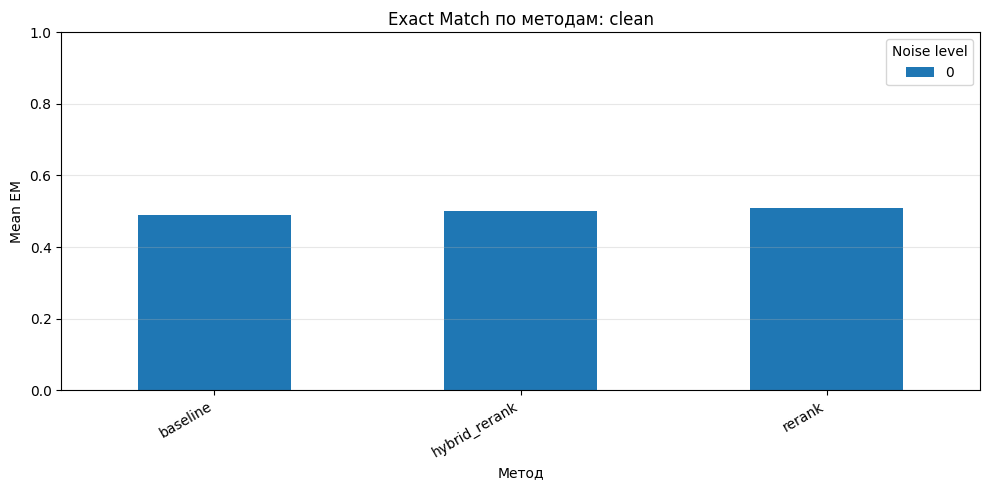

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/em_by_method_clean.png


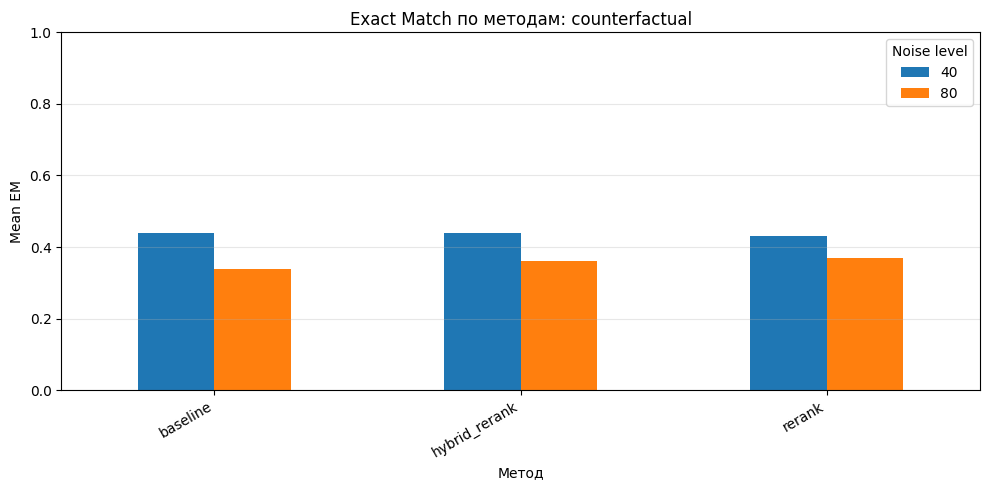

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/em_by_method_counterfactual.png


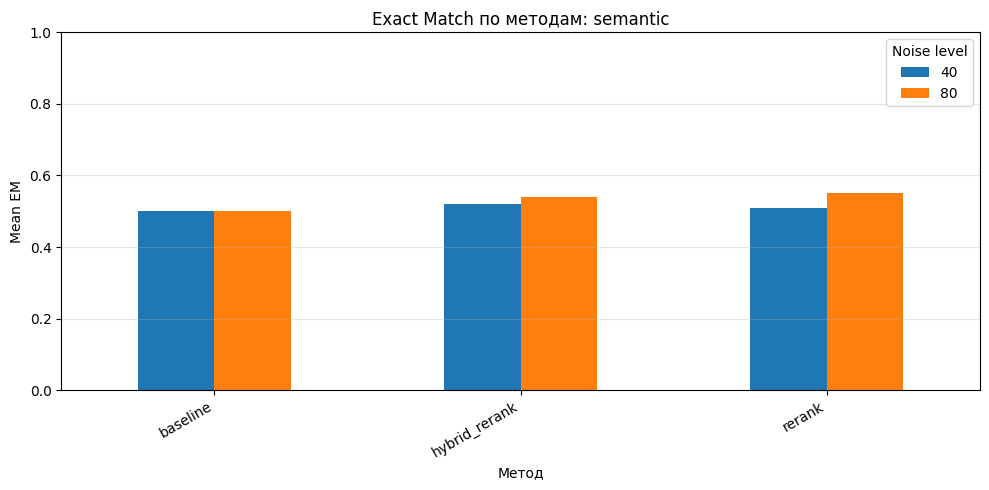

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/em_by_method_semantic.png


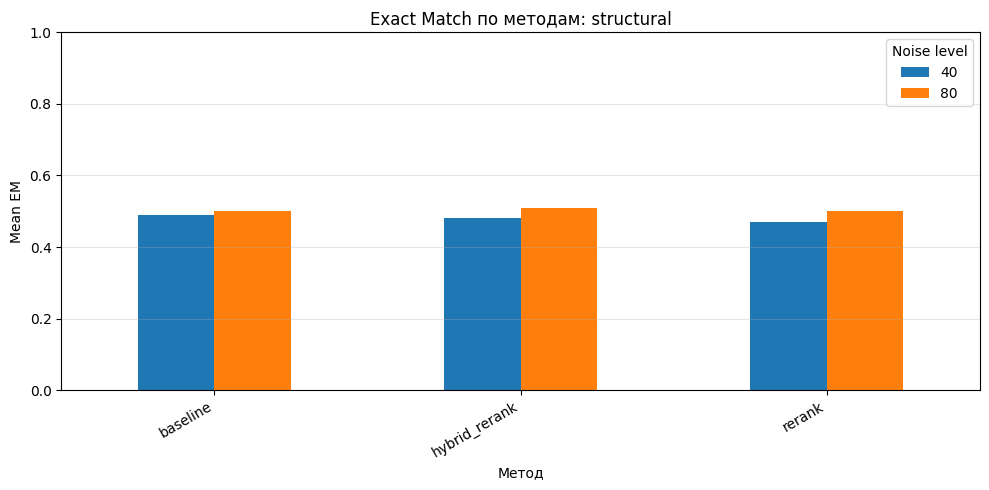

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/em_by_method_structural.png


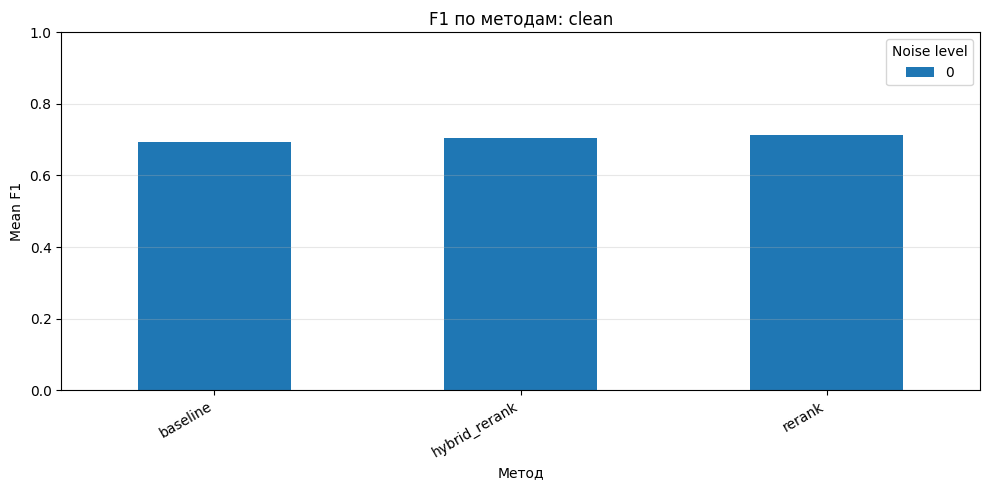

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/f1_by_method_clean.png


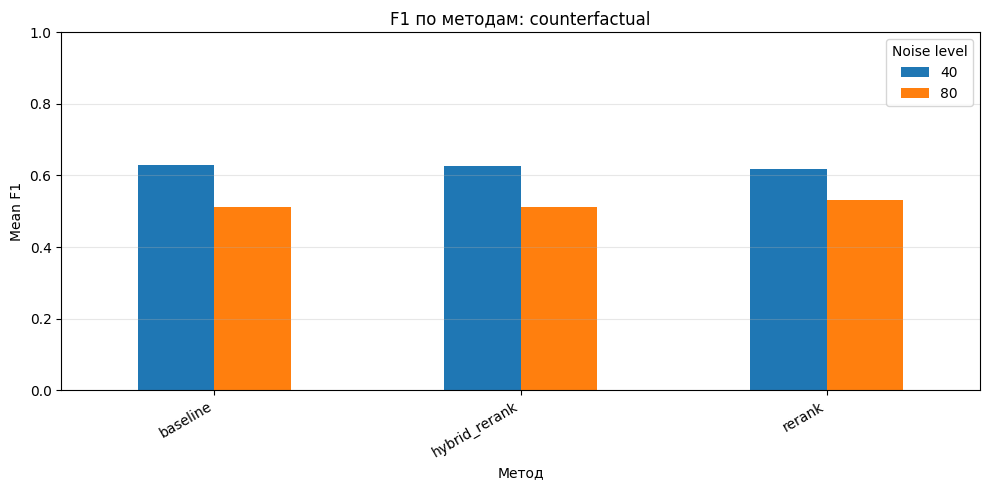

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/f1_by_method_counterfactual.png


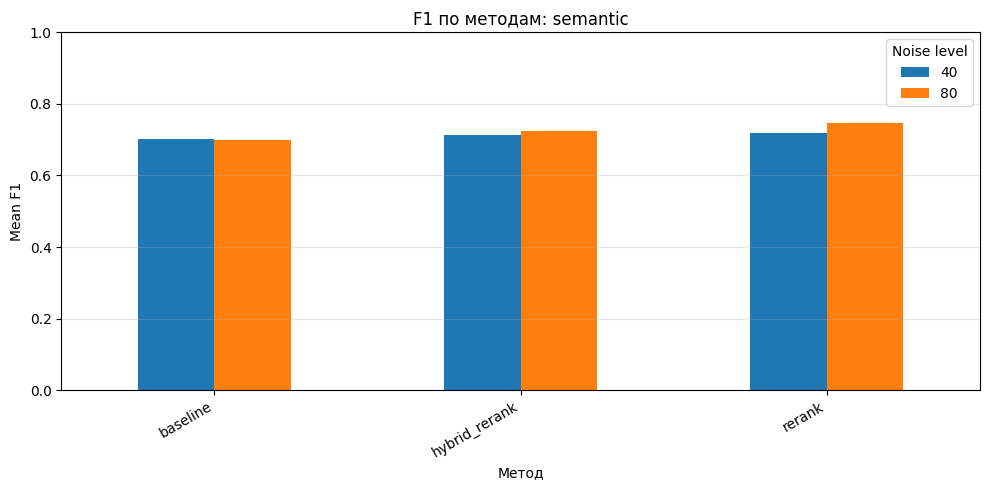

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/f1_by_method_semantic.png


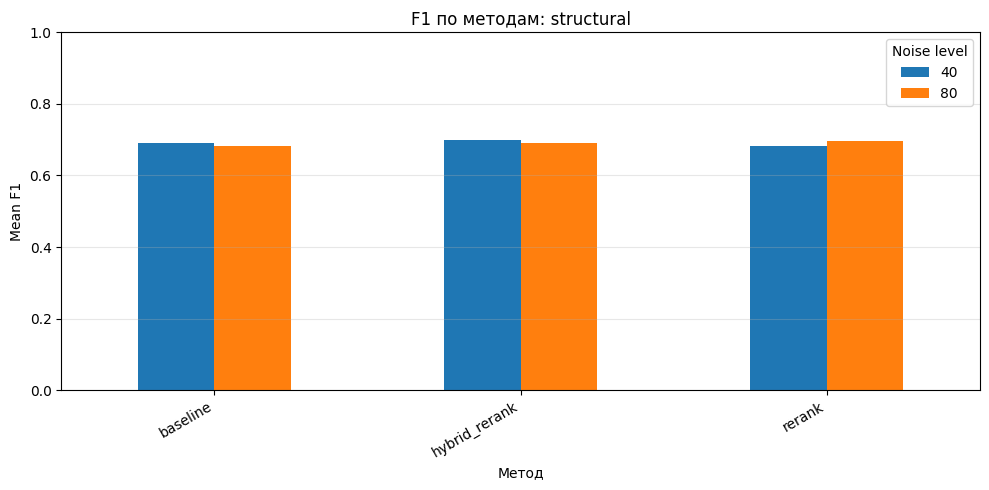

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/f1_by_method_structural.png


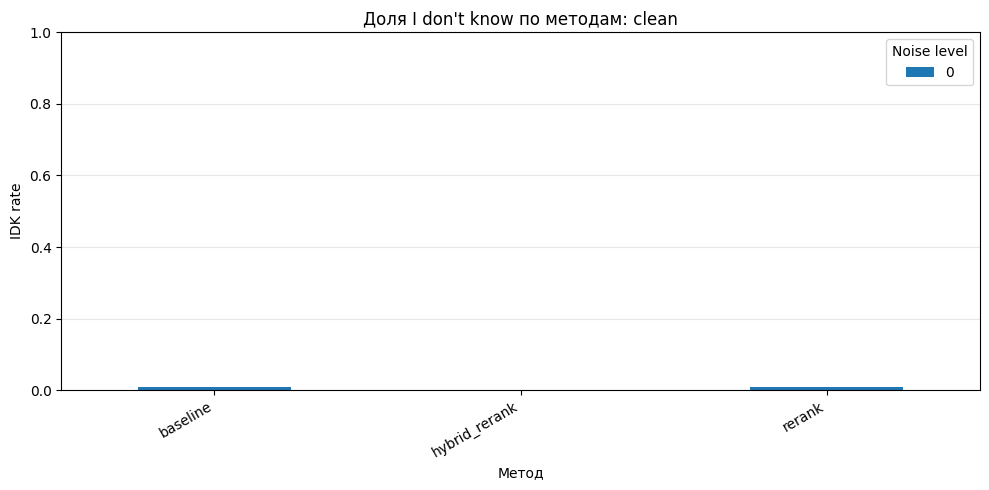

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/idk_rate_by_method_clean.png


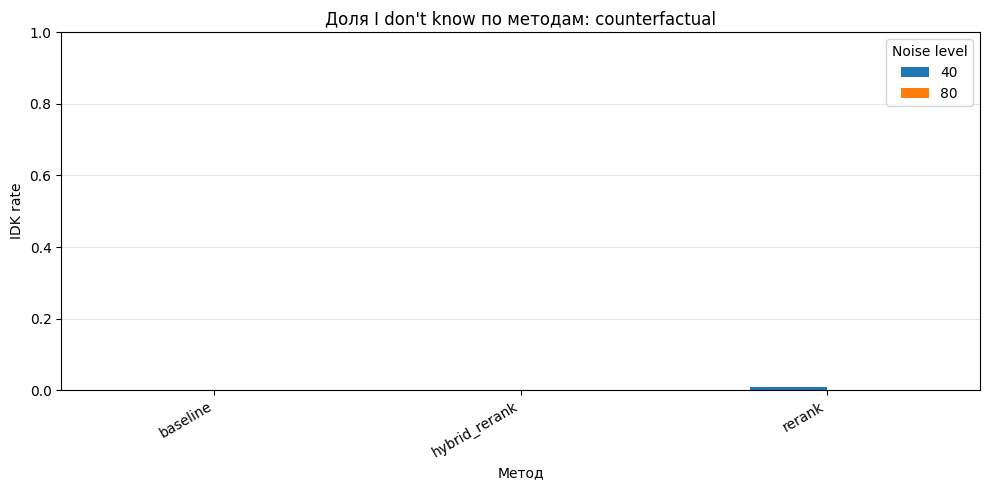

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/idk_rate_by_method_counterfactual.png


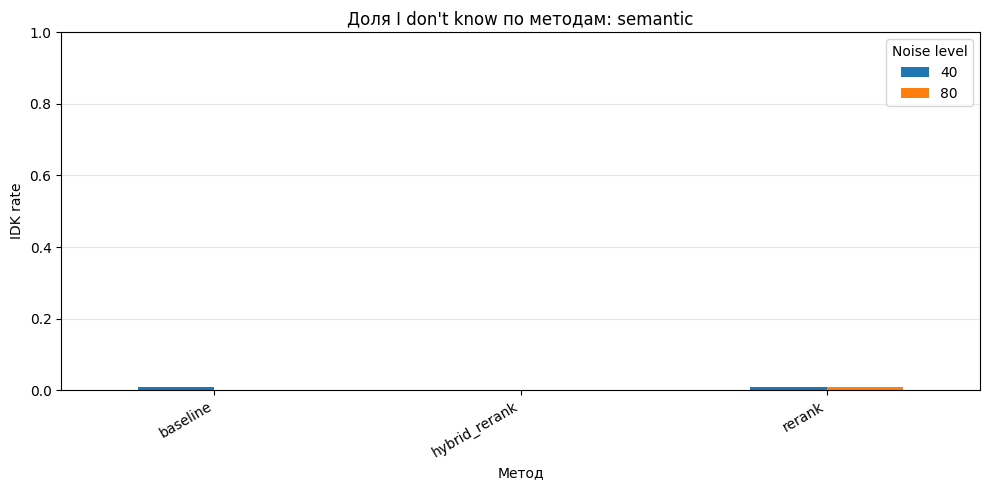

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/idk_rate_by_method_semantic.png


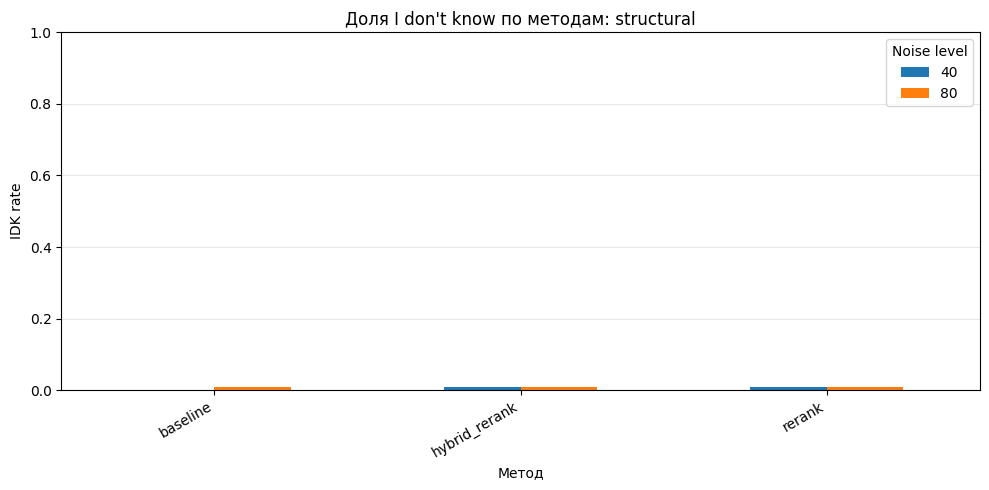

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/idk_rate_by_method_structural.png


In [21]:
# 1) Основные answer-метрики: EM, F1, I don't know rate
bar_by_noise_level(plot_summary, "EM", "Exact Match по методам", "Mean EM", "em_by_method")
bar_by_noise_level(plot_summary, "F1", "F1 по методам", "Mean F1", "f1_by_method")
bar_by_noise_level(plot_summary, "idk_rate", "Доля I don't know по методам", "IDK rate", "idk_rate_by_method")


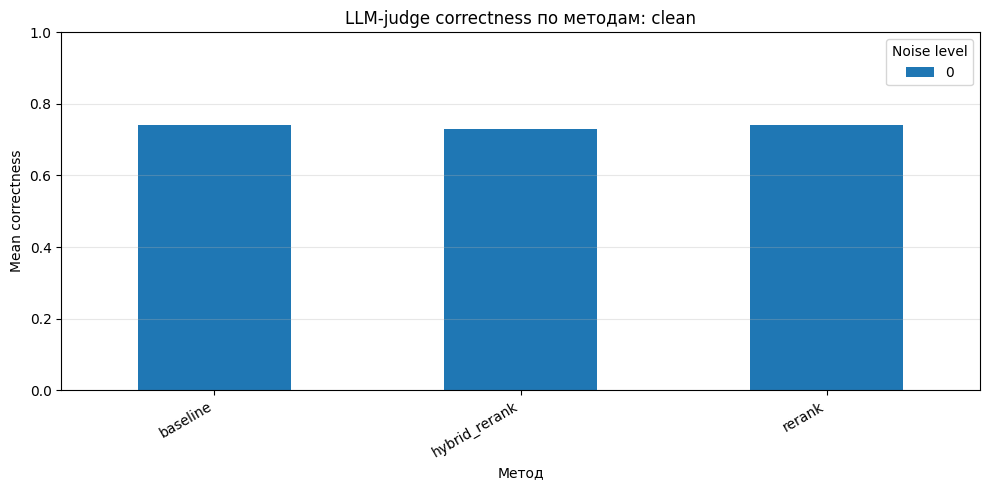

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/llm_correctness_by_method_clean.png


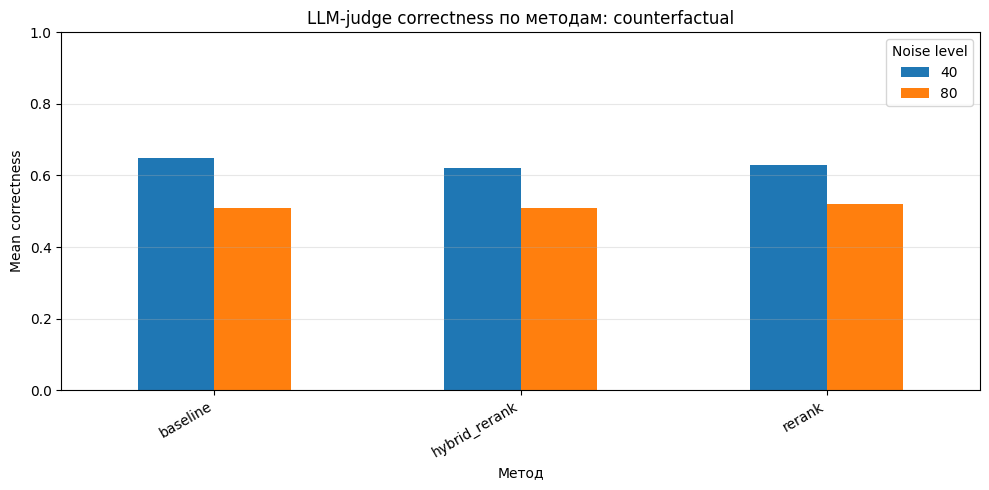

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/llm_correctness_by_method_counterfactual.png


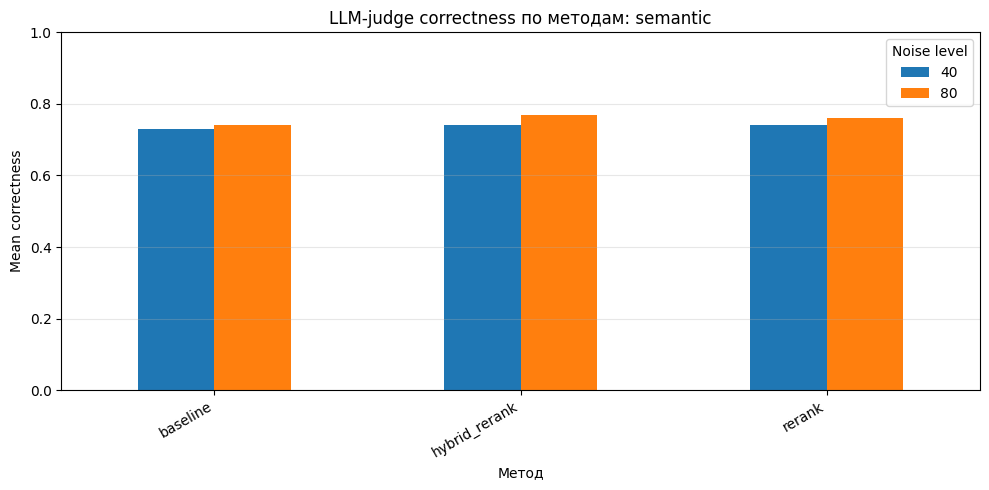

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/llm_correctness_by_method_semantic.png


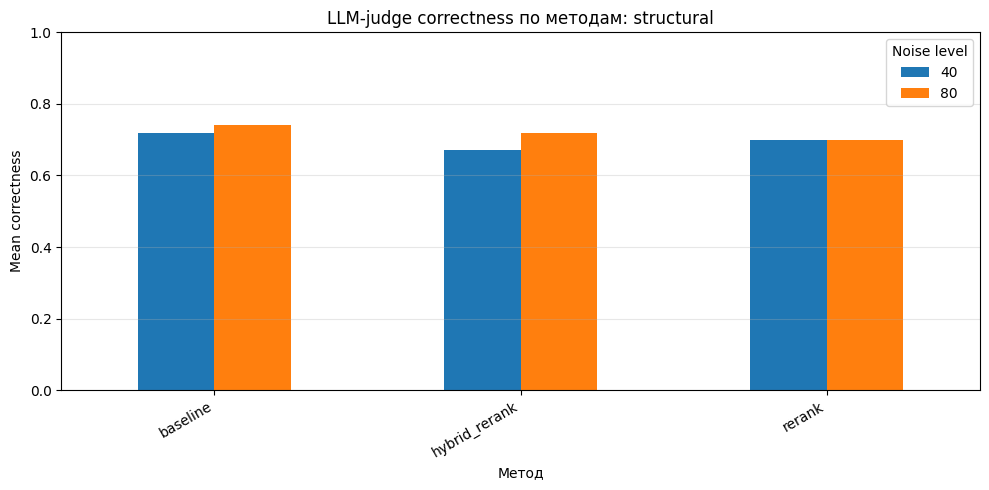

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/llm_correctness_by_method_structural.png


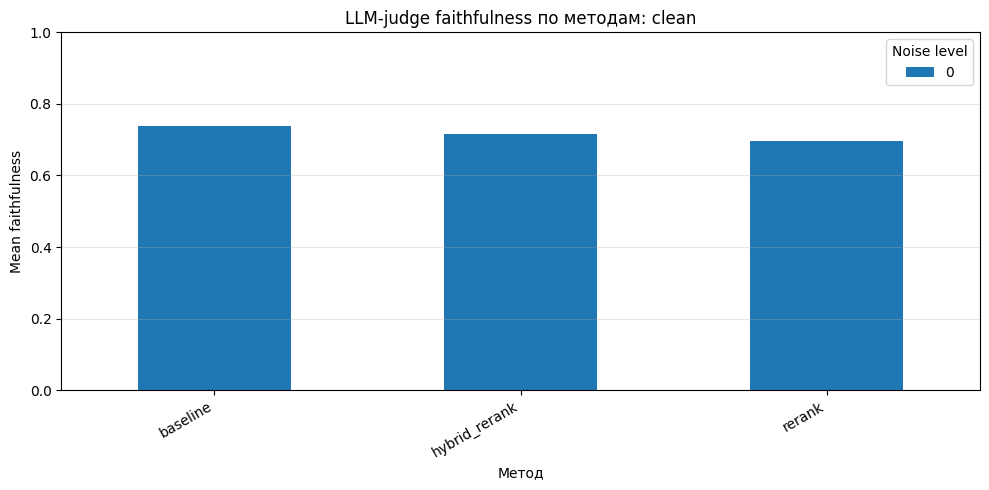

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/llm_faithfulness_by_method_clean.png


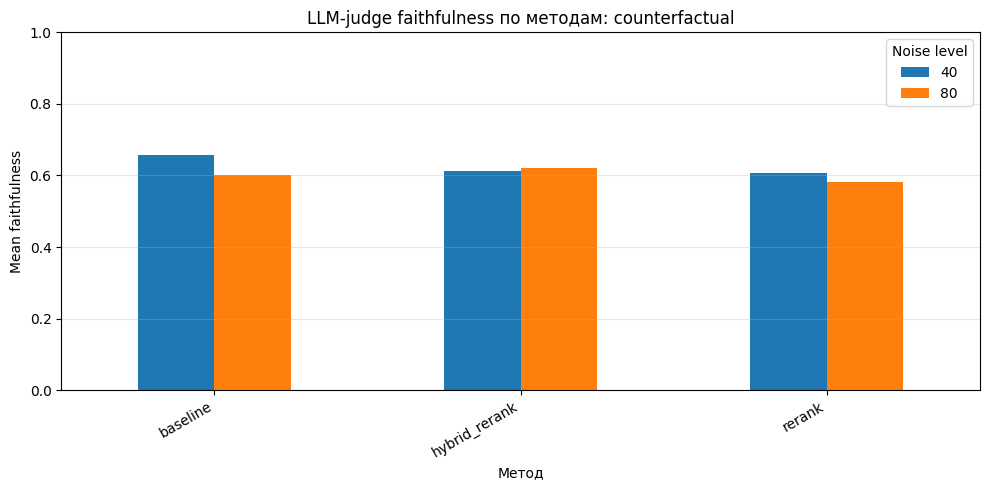

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/llm_faithfulness_by_method_counterfactual.png


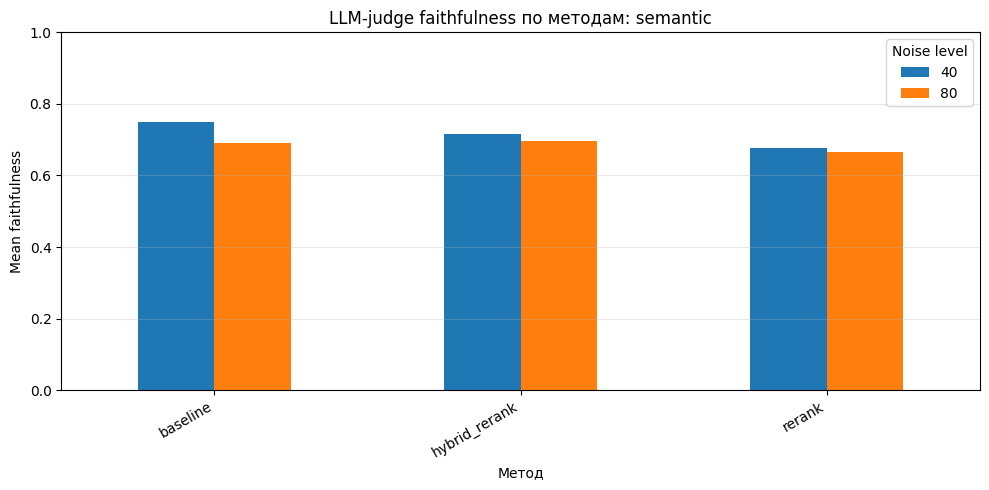

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/llm_faithfulness_by_method_semantic.png


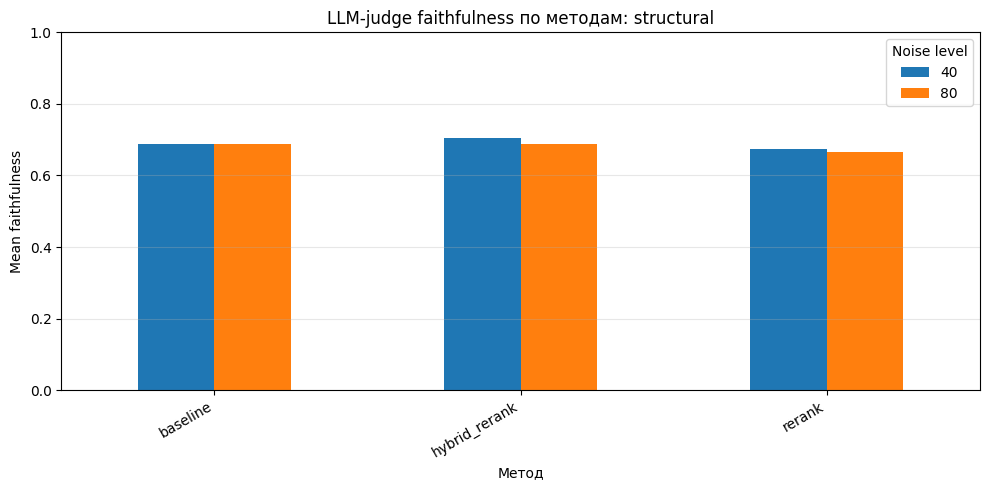

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/llm_faithfulness_by_method_structural.png


In [22]:
# 2) LLM-as-a-judge: correctness и faithfulness
# Эти графики появятся только если выше был запущен Шаг 13 и сформирована таблица с LLM-оценкой.
bar_by_noise_level(plot_summary, "correctness_score", "LLM-judge correctness по методам", "Mean correctness", "llm_correctness_by_method")
bar_by_noise_level(plot_summary, "faithfulness_score", "LLM-judge faithfulness по методам", "Mean faithfulness", "llm_faithfulness_by_method")


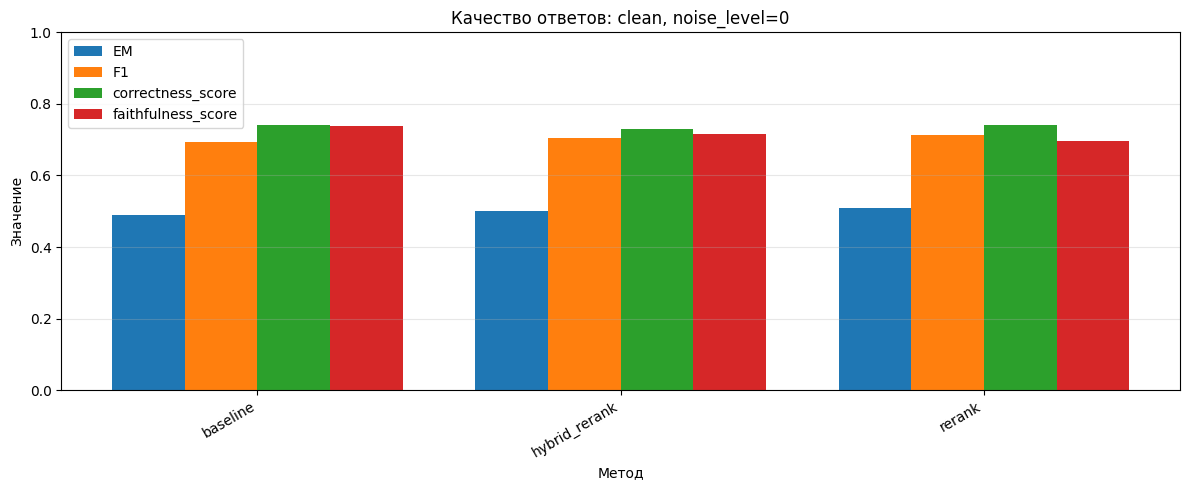

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/answer_metrics_clean_lvl0.png


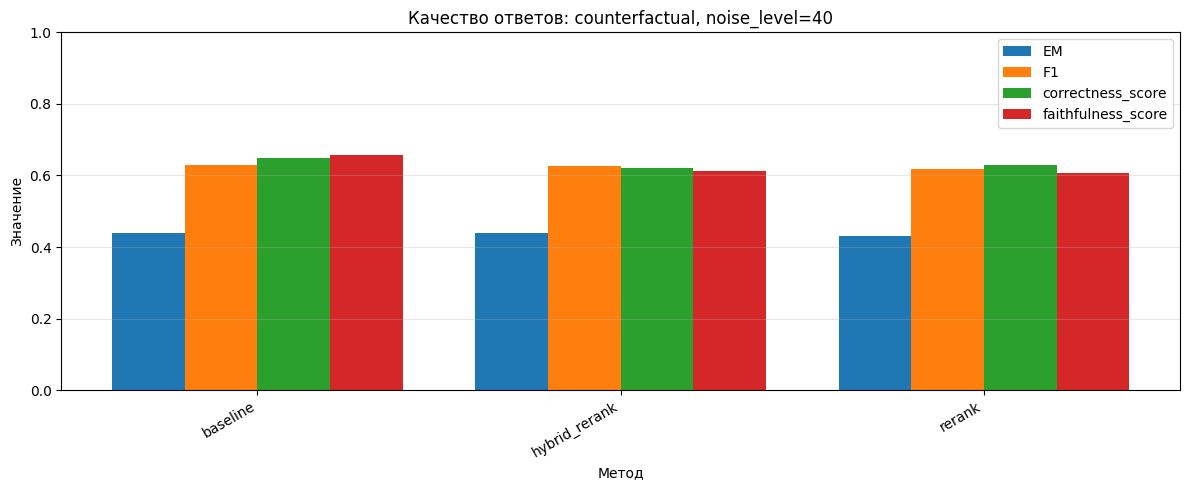

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/answer_metrics_counterfactual_lvl40.png


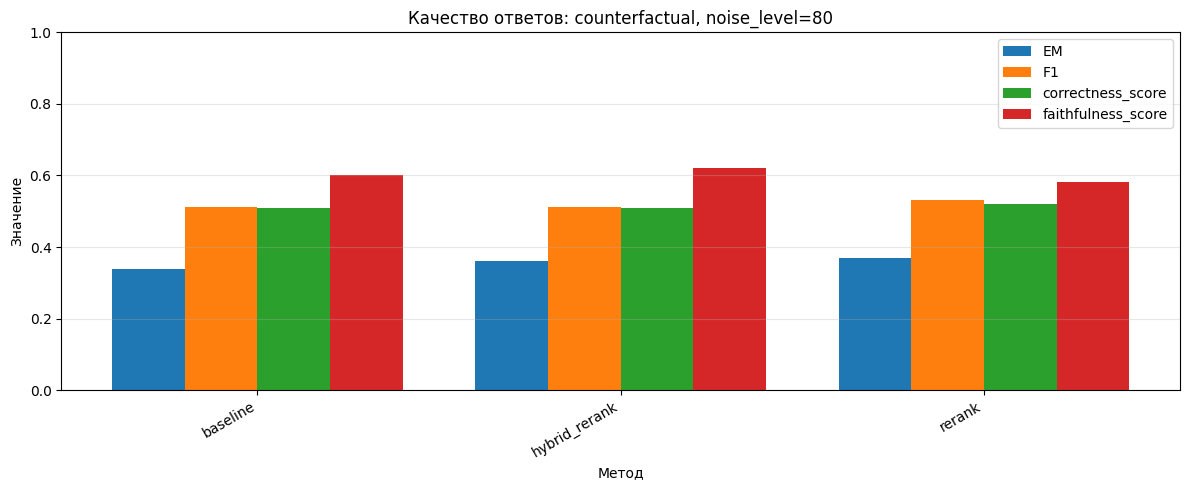

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/answer_metrics_counterfactual_lvl80.png


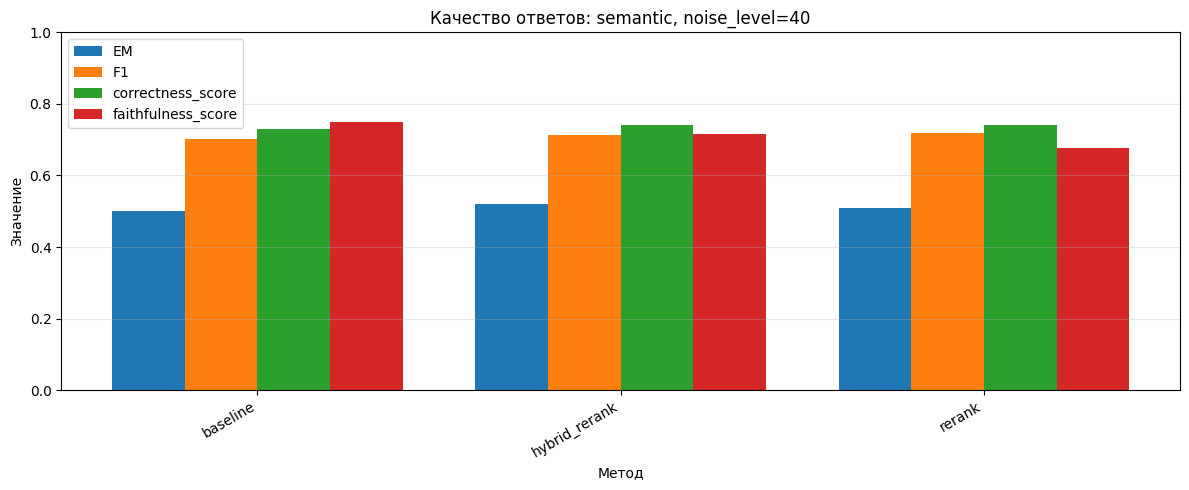

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/answer_metrics_semantic_lvl40.png


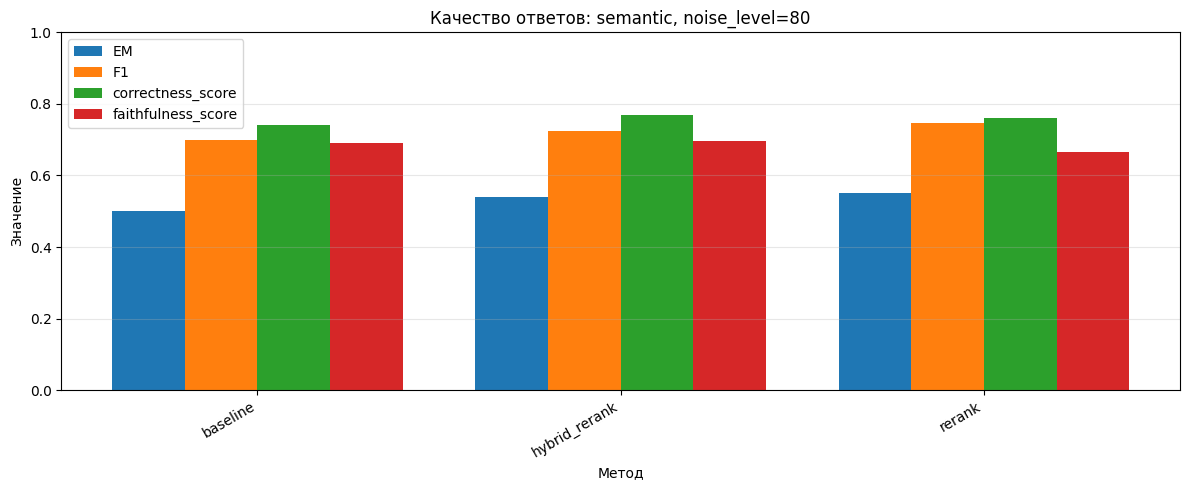

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/answer_metrics_semantic_lvl80.png


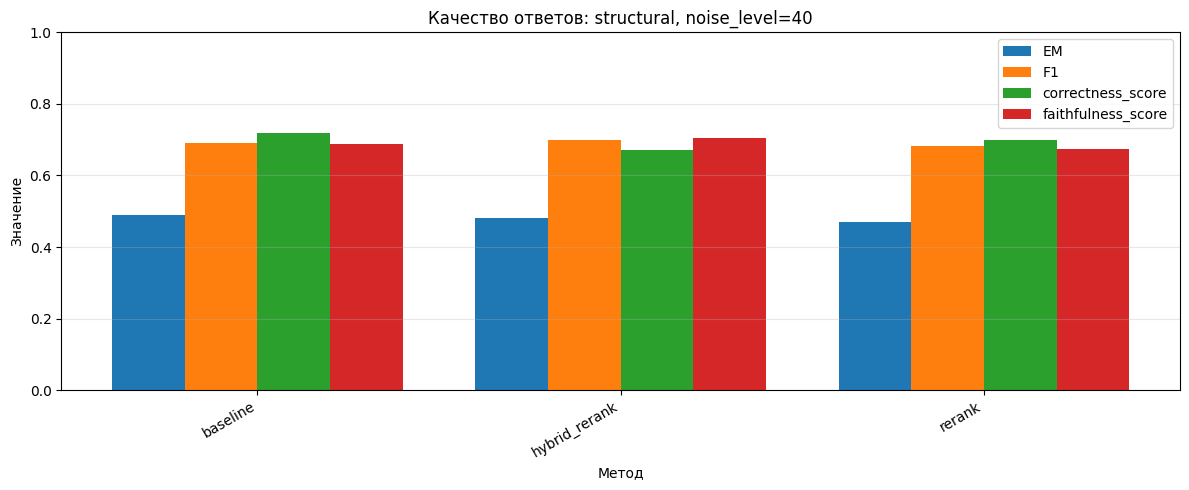

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/answer_metrics_structural_lvl40.png


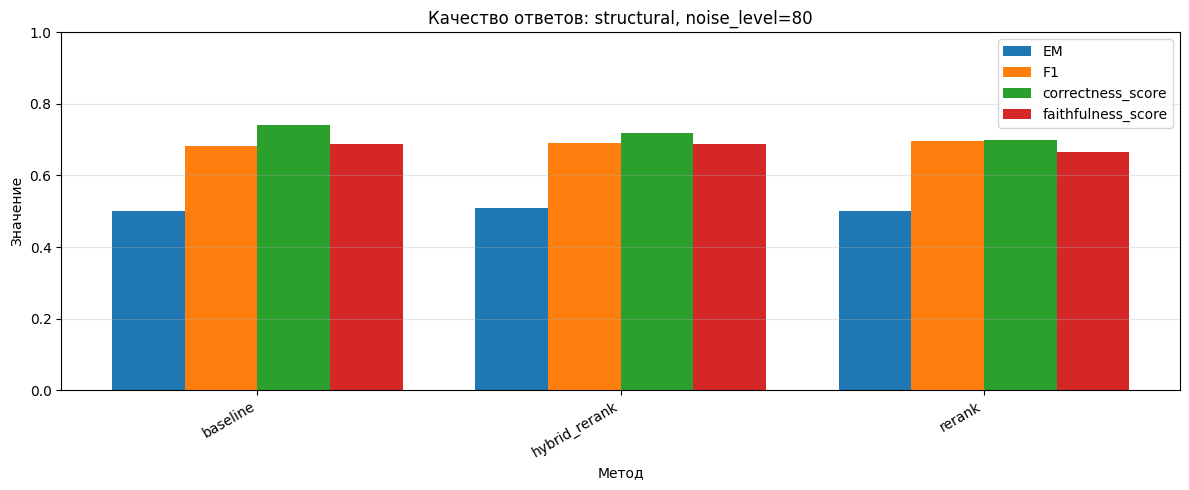

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/answer_metrics_structural_lvl80.png


In [23]:
# 3) Сравнение EM/F1/LLM-judge на одном графике для каждой пары noise_type × noise_level
metrics_to_plot = [c for c in ["EM", "F1", "correctness_score", "faithfulness_score"] if c in plot_summary.columns]

if not metrics_to_plot:
    print("Нет метрик для сравнения")
else:
    for noise_type in sorted(plot_summary["noise_type"].dropna().unique()):
        for noise_level in sorted(plot_summary["noise_level"].dropna().unique()):
            d = plot_summary[(plot_summary["noise_type"] == noise_type) & (plot_summary["noise_level"] == noise_level)].copy()
            d = d.dropna(subset=metrics_to_plot, how="all")
            if d.empty:
                continue

            x = np.arange(len(d["method"]))
            width = 0.8 / max(len(metrics_to_plot), 1)
            fig, ax = plt.subplots(figsize=(12, 5))

            for i, metric in enumerate(metrics_to_plot):
                ax.bar(x + i * width, d[metric], width=width, label=metric)

            ax.set_title(f"Качество ответов: {noise_type}, noise_level={noise_level}")
            ax.set_xlabel("Метод")
            ax.set_ylabel("Значение")
            ax.set_ylim(0, 1)
            ax.set_xticks(x + width * (len(metrics_to_plot) - 1) / 2)
            ax.set_xticklabels(d["method"], rotation=30, ha="right")
            ax.grid(axis="y", alpha=0.3)
            ax.legend()

            safe_noise = str(noise_type).replace("/", "_")
            save_and_show(fig, f"answer_metrics_{safe_noise}_lvl{int(noise_level)}.png")


/tmp/ipykernel_3058/4106500644.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  ret_plot[col] = pd.to_numeric(ret_plot[col], errors="ignore")


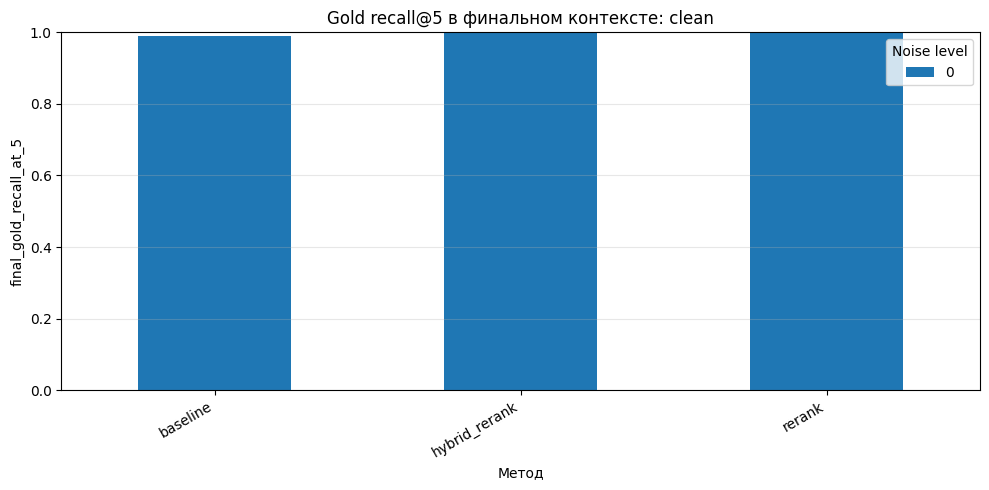

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_gold_recall_at5_clean.png


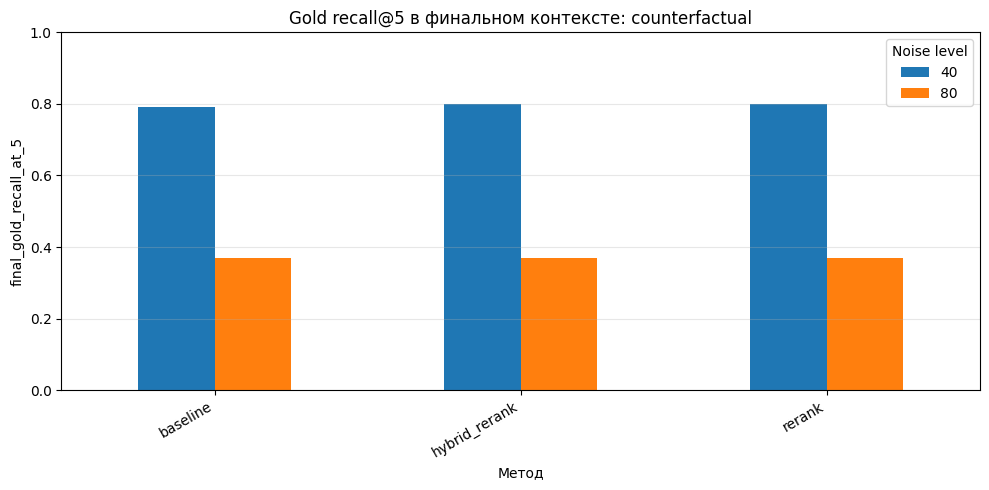

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_gold_recall_at5_counterfactual.png


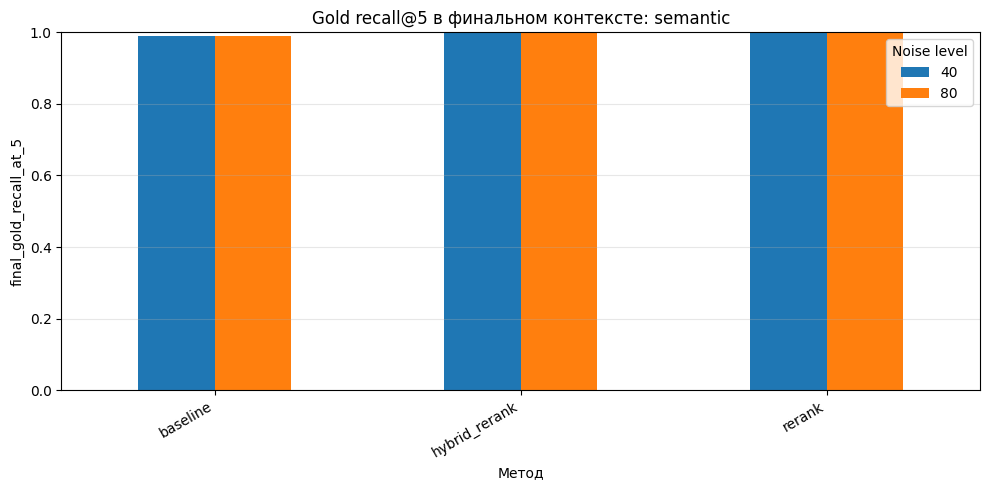

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_gold_recall_at5_semantic.png


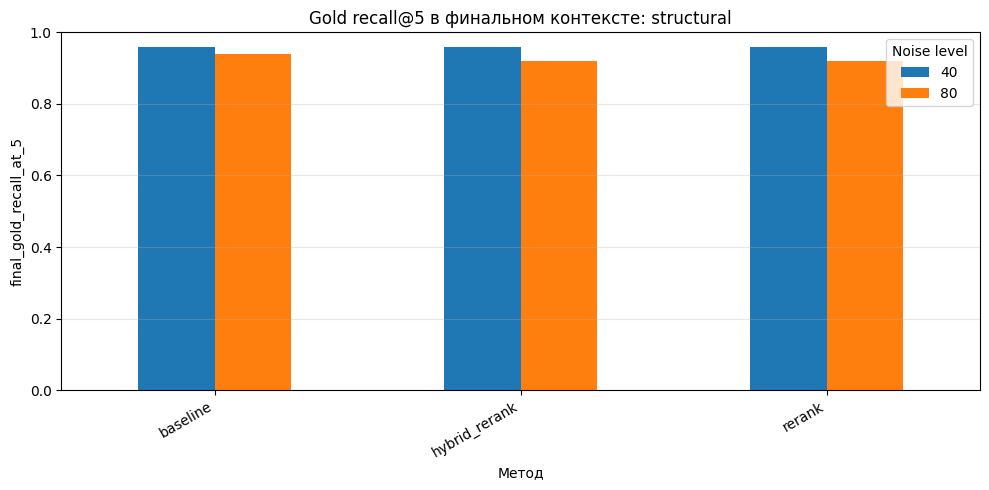

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_gold_recall_at5_structural.png


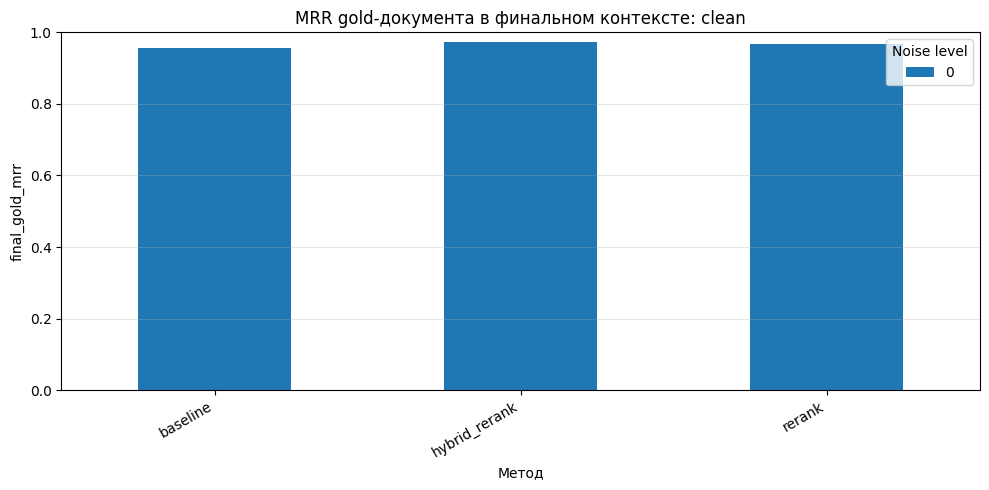

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_gold_mrr_clean.png


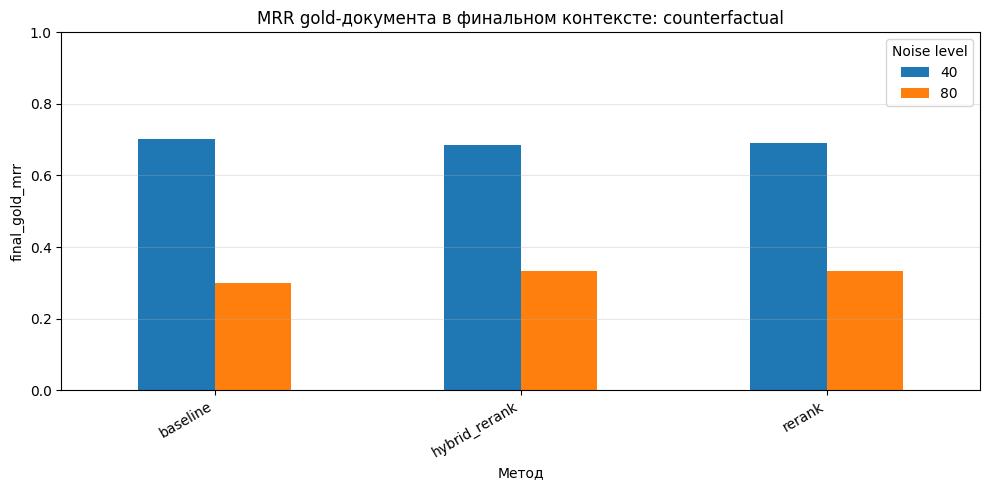

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_gold_mrr_counterfactual.png


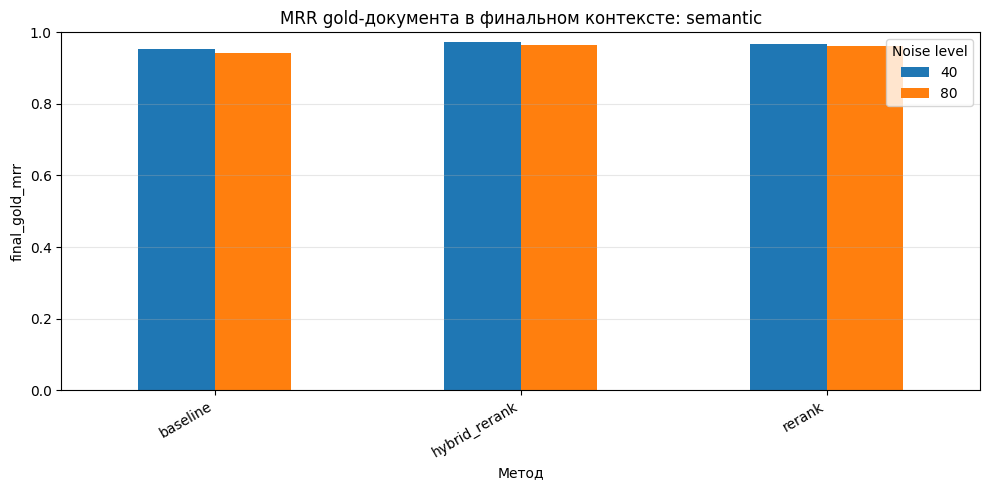

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_gold_mrr_semantic.png


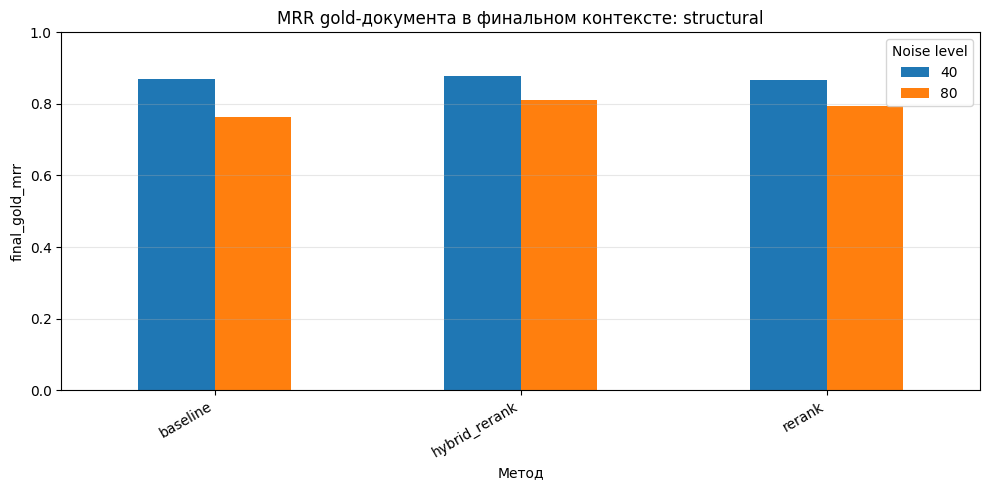

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_gold_mrr_structural.png


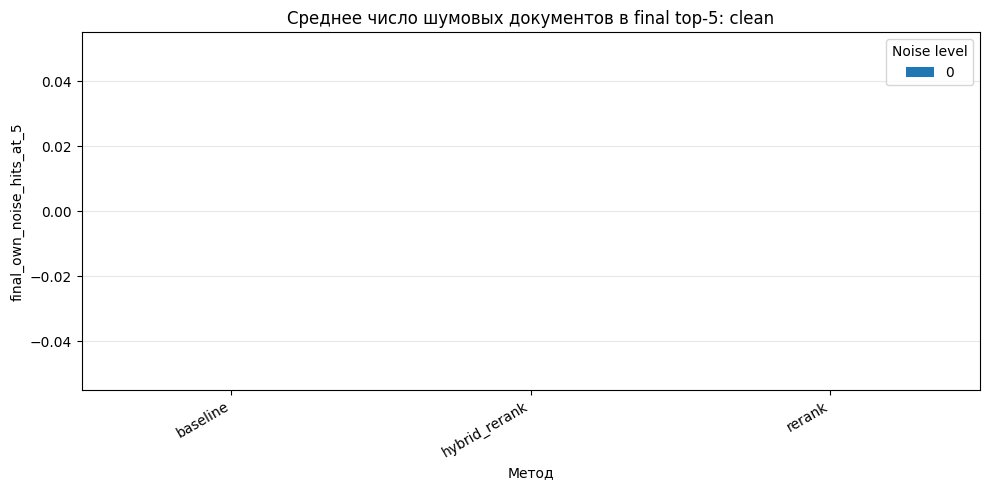

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_noise_hits_at5_clean.png


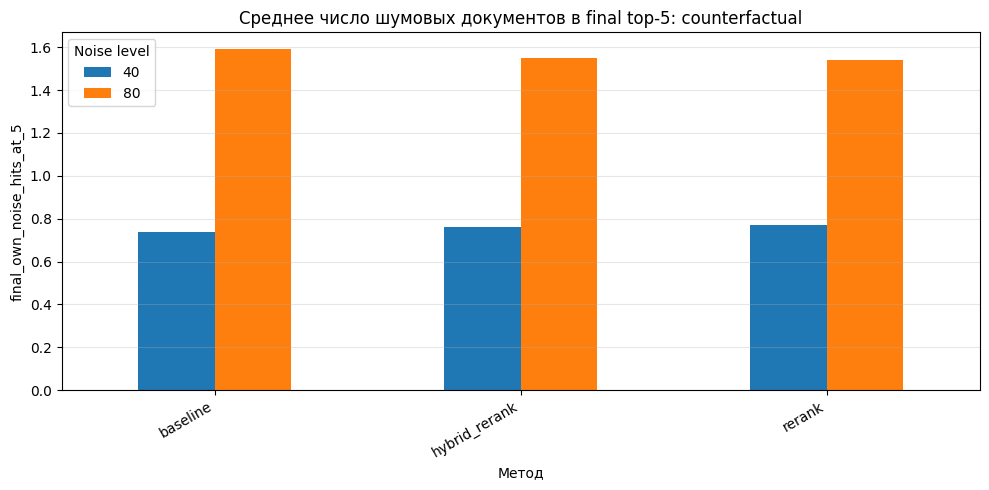

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_noise_hits_at5_counterfactual.png


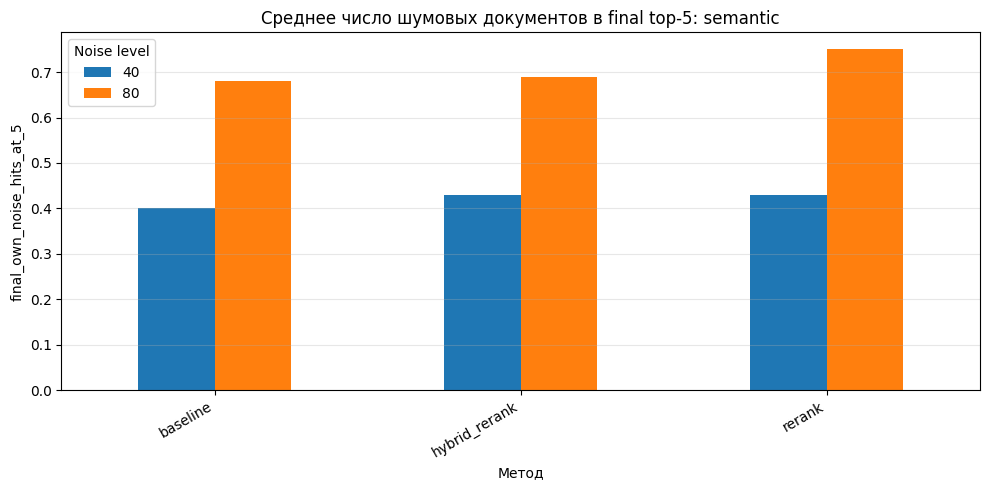

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_noise_hits_at5_semantic.png


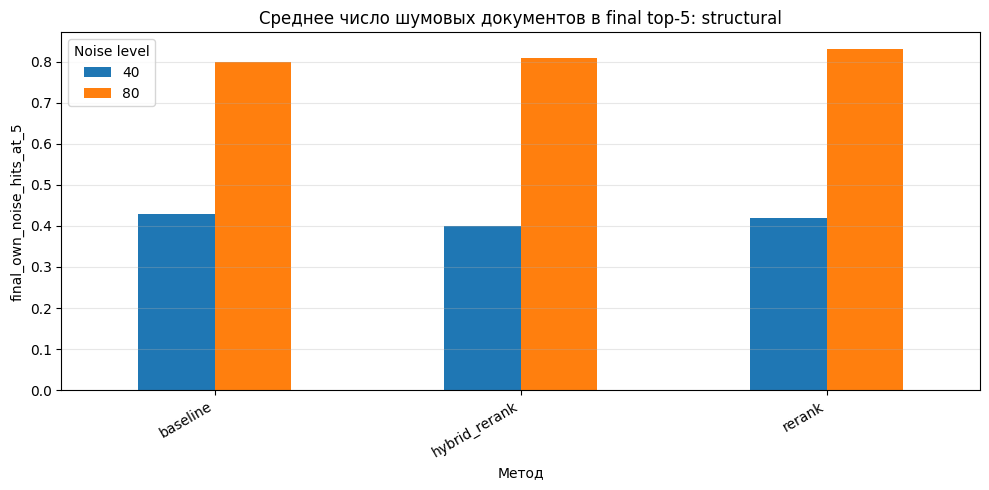

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/final_noise_hits_at5_structural.png


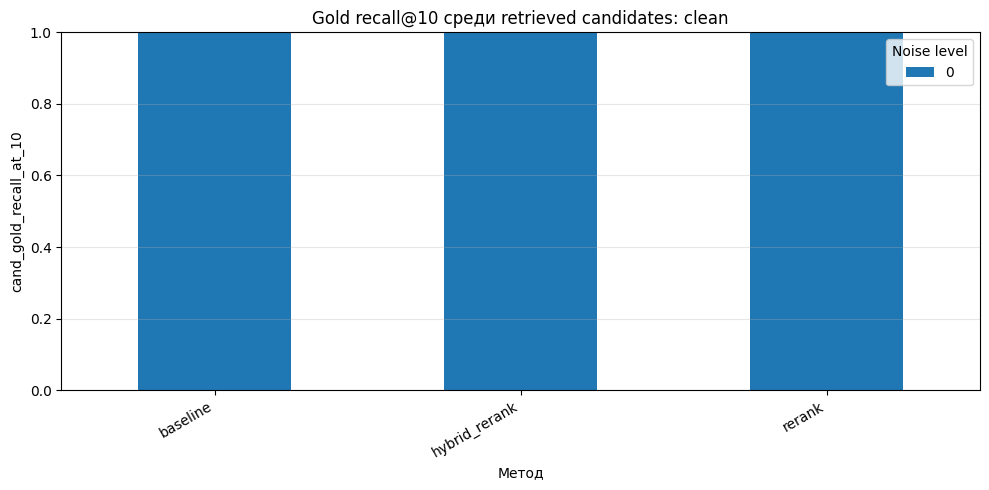

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/candidate_gold_recall_at10_clean.png


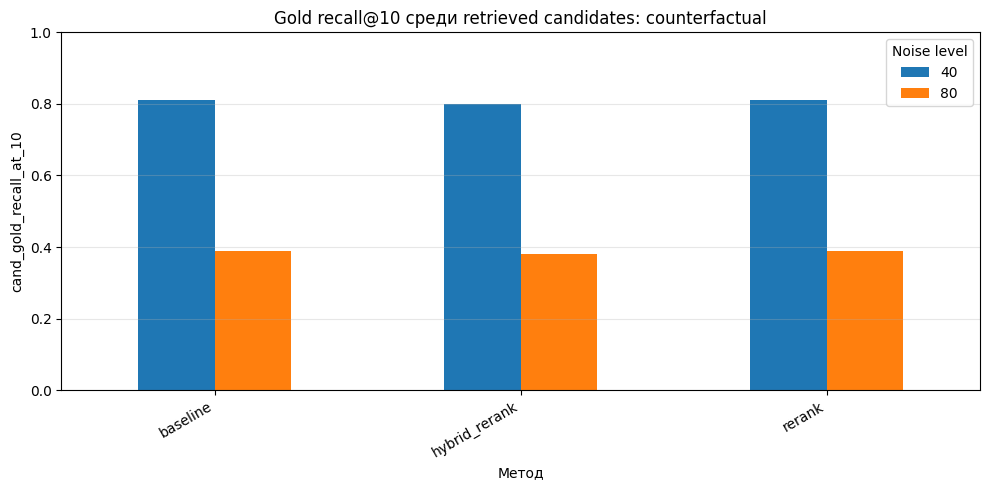

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/candidate_gold_recall_at10_counterfactual.png


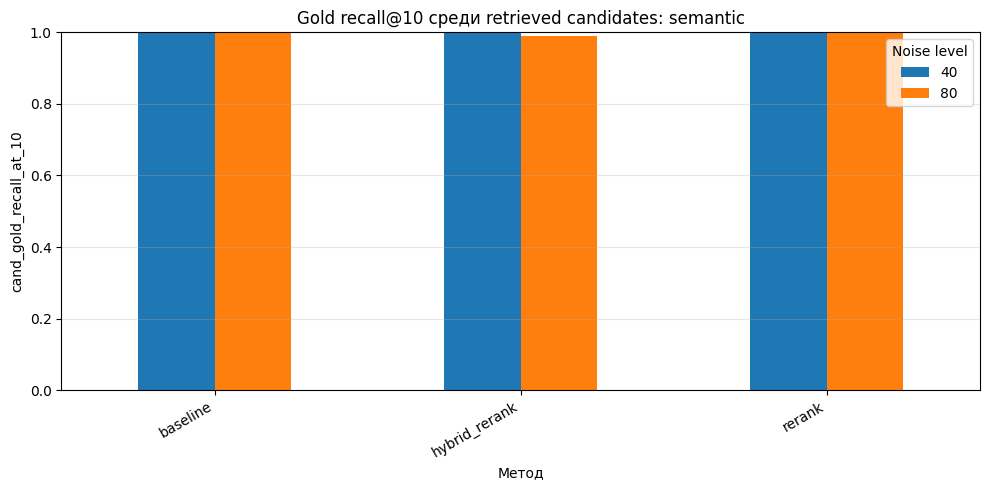

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/candidate_gold_recall_at10_semantic.png


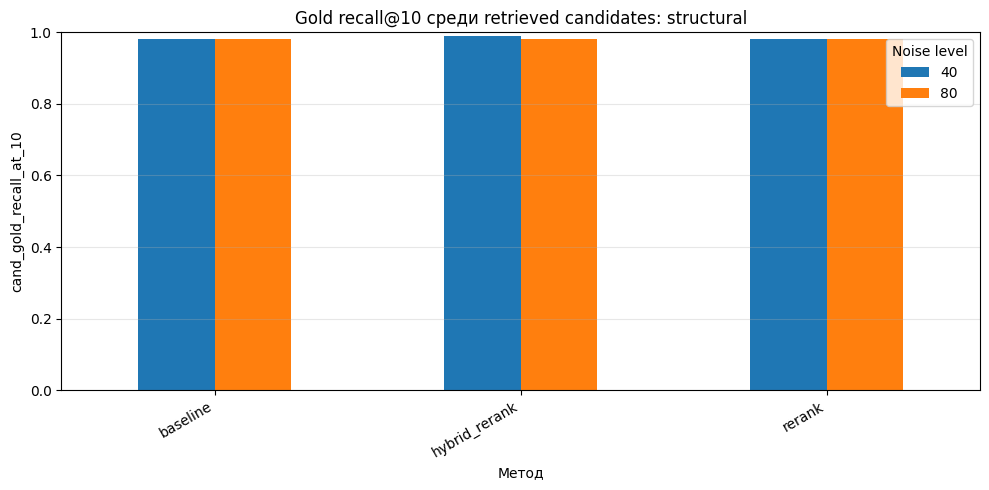

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/candidate_gold_recall_at10_structural.png


In [24]:
# 4) Retrieval-графики: помогают понять, где методы реально улучшают retrieval, а где только генерацию.
# Используем summary_df, потому что в ней есть расширенные retrieval-метрики.
ret_plot = summary_df.copy()
for col in ret_plot.columns:
    if col not in ["method", "noise_type", "collection"]:
        ret_plot[col] = pd.to_numeric(ret_plot[col], errors="ignore")

for metric, title, fname in [
    ("final_gold_recall_at_5", "Gold recall@5 в финальном контексте", "final_gold_recall_at5"),
    ("final_gold_mrr", "MRR gold-документа в финальном контексте", "final_gold_mrr"),
    ("final_own_noise_hits_at_5", "Среднее число шумовых документов в final top-5", "final_noise_hits_at5"),
    ("cand_gold_recall_at_10", "Gold recall@10 среди retrieved candidates", "candidate_gold_recall_at10"),
]:
    ylim = None if "noise_hits" in metric else (0, 1)
    bar_by_noise_level(ret_plot, metric, title, metric, fname, ylim=ylim)


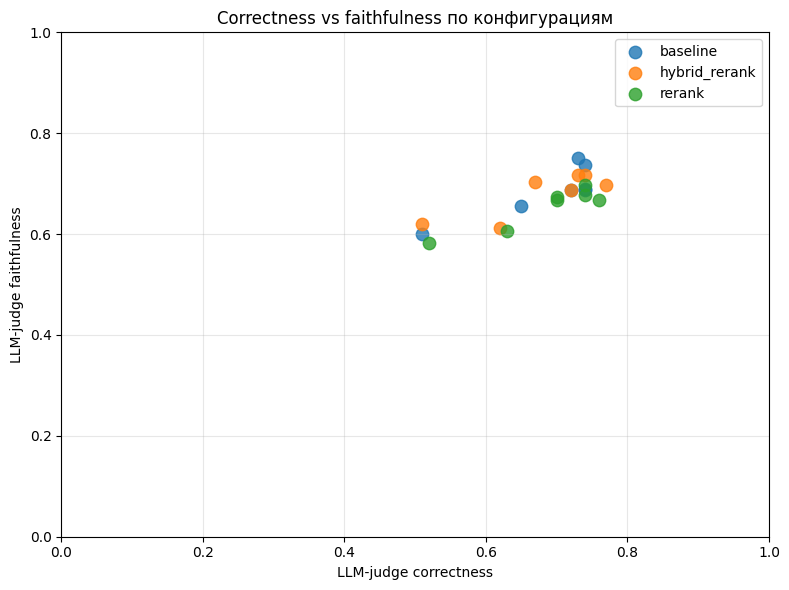

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/correctness_vs_faithfulness.png


In [25]:
# 5) Correctness vs faithfulness — важный график для контрафактического шума.
# Он показывает случаи, когда ответ хорошо поддержан контекстом, но может быть неверен относительно gold.
if {"correctness_score", "faithfulness_score"}.issubset(plot_summary.columns):
    d = plot_summary.dropna(subset=["correctness_score", "faithfulness_score"]).copy()
    if d.empty:
        print("Нет данных correctness/faithfulness для scatter-графика")
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        for method in sorted(d["method"].dropna().unique()):
            m = d[d["method"] == method]
            ax.scatter(m["correctness_score"], m["faithfulness_score"], s=80, alpha=0.8, label=method)
        ax.set_xlabel("LLM-judge correctness")
        ax.set_ylabel("LLM-judge faithfulness")
        ax.set_title("Correctness vs faithfulness по конфигурациям")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend()
        save_and_show(fig, "correctness_vs_faithfulness.png")
else:
    print("Колонок correctness_score и faithfulness_score пока нет. Запусти Шаг 13–14 для LLM-judge.")


Correlation F1 vs LLM-correctness: 0.682


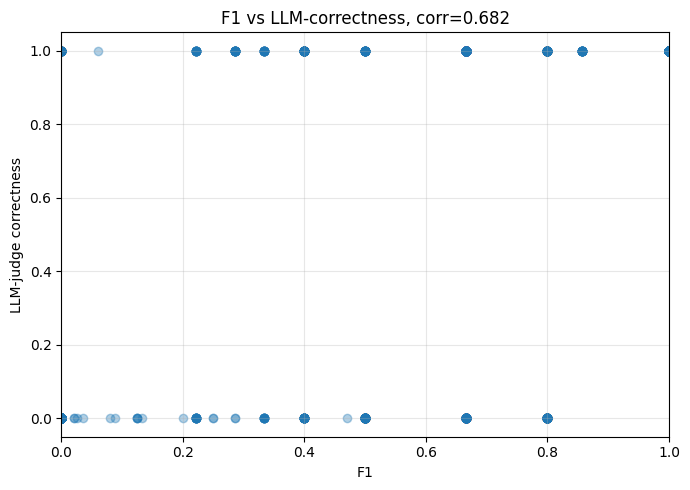

Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/plots/f1_vs_llm_correctness.png


In [26]:
# 6) Корреляция F1 и LLM-correctness на уровне отдельных ответов
if "judge_df" in globals() and isinstance(judge_df, pd.DataFrame) and {"F1", "correctness_score"}.issubset(judge_df.columns):
    d = judge_df.copy()
    d["F1"] = pd.to_numeric(d["F1"], errors="coerce")
    d["correctness_score"] = pd.to_numeric(d["correctness_score"], errors="coerce")
    d = d.dropna(subset=["F1", "correctness_score"])
    if d.empty:
        print("Нет данных для корреляции F1 и correctness")
    else:
        corr = d["F1"].corr(d["correctness_score"])
        print(f"Correlation F1 vs LLM-correctness: {corr:.3f}")
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(d["F1"], d["correctness_score"], alpha=0.35)
        ax.set_xlabel("F1")
        ax.set_ylabel("LLM-judge correctness")
        ax.set_title(f"F1 vs LLM-correctness, corr={corr:.3f}")
        ax.set_xlim(0, 1)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        save_and_show(fig, "f1_vs_llm_correctness.png")
else:
    print("judge_df с correctness_score пока нет. Запусти Шаг 13–14 для LLM-judge.")


In [27]:
# 7) Финальная таблица для вставки в диплом
cols = [
    "noise_type", "noise_level", "method",
    "n" if "n" in plot_summary.columns else "n_records",
    "EM", "F1", "idk_rate",
    "correctness_score", "faithfulness_score",
]
cols = [c for c in cols if c in plot_summary.columns]
final_table = plot_summary[cols].sort_values(["noise_type", "noise_level", "method"]).copy()

out_plot_summary = EVAL_DIR / "041_e2e_natural_plot_summary.csv"
final_table.to_csv(out_plot_summary, index=False)
print("Saved:", out_plot_summary)
display(final_table)


Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_natural/041_e2e_natural_plot_summary.csv


,noise_type,noise_level,method,n,EM,F1,idk_rate,correctness_score,faithfulness_score
0,clean,0,baseline,100,0.49,0.692996,0.01,0.74,0.737374
7,clean,0,hybrid_rerank,100,0.50,0.704873,0.00,0.73,0.717172
14,clean,0,rerank,100,0.51,0.713540,0.01,0.74,0.696970
1,counterfactual,40,baseline,100,0.44,0.628567,0.00,0.65,0.656566
8,counterfactual,40,hybrid_rerank,100,0.44,0.625984,0.00,0.62,0.612245
15,counterfactual,40,rerank,100,0.43,0.618023,0.01,0.63,0.606061
2,counterfactual,80,baseline,100,0.34,0.512558,0.00,0.51,0.600000
9,counterfactual,80,hybrid_rerank,100,0.36,0.512586,0.00,0.51,0.620000
16,counterfactual,80,rerank,100,0.37,0.532262,0.00,0.52,0.581633
3,semantic,40,baseline,100,0.50,0.700807,0.01,0.73,0.750000


## Шаг 15. Быстрый просмотр случайных примеров

In [28]:
sample_records = random.sample(records, min(5, len(records)))
for i, rec in enumerate(sample_records, 1):
    print("=" * 100)
    print(f"[{i}] {rec.get('method')} | {rec.get('noise_type')} | lvl={rec.get('noise_level')} | qid={rec.get('qid')}")
    print("Q:", rec.get("question"))
    print("Gold:", rec.get("gold"))
    print("Pred:", rec.get("predicted"))
    print("Candidate metrics:", rec.get("candidate_metrics"))
    print("Final metrics:", rec.get("final_context_metrics"))
    print("Final roles:", [d.get("role") for d in rec.get("final_context", [])])


[1] baseline | counterfactual | lvl=80 | qid=5a80ae105542992bc0c4a7a2
Q: What occupation is shared by both Marge Piercy and Richard Aldington?
Gold: poet
Pred: Novelist
Candidate metrics: {'gold_recall_at_3': 0.0, 'related_recall_at_3': 1.0, 'own_noise_hits_at_3': 2, 'injected_hits_at_3': 2, 'own_noise_share_at_3': 0.6666666666666666, 'roles_at_3': {'injected_counterfactual': 2, 'distractor': 1}, 'gold_recall_at_5': 0.0, 'related_recall_at_5': 1.0, 'own_noise_hits_at_5': 2, 'injected_hits_at_5': 2, 'own_noise_share_at_5': 0.4, 'roles_at_5': {'injected_counterfactual': 2, 'distractor': 3}, 'gold_recall_at_10': 0.0, 'related_recall_at_10': 1.0, 'own_noise_hits_at_10': 3, 'injected_hits_at_10': 3, 'own_noise_share_at_10': 0.3, 'roles_at_10': {'injected_counterfactual': 3, 'distractor': 5, 'background': 2}, 'gold_best_rank': None, 'gold_mrr': 0.0, 'related_best_rank': 1, 'related_mrr': 1.0, 'gold_titles': ['Marge Piercy', 'Richard Aldington']}
Final metrics: {'gold_recall_at_3': 0.0, 'rela